In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
# Importation des bibliothèques nécessaires pour
# - la manipulation de données (pandas, numpy)
# - la normalisation des variables numériques (StandardScaler)

# Chargement des jeux de données d'entraînement et de test
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

In [ ]:
# Importation des bibliothèques nécessaires : pandas pour la manipulation des données,
# numpy pour les calculs numériques, et des outils de preprocessing de scikit-learn.
# Chargement des fichiers d'entraînement et de test fournis par Kaggle.

In [3]:
# Exploration initiale des données (EDA basique)
train.head()
train.info()
train.describe()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  str    
 3   course            630000 non-null  str    
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  str    
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  str    
 9   study_method      630000 non-null  str    
 10  facility_rating   630000 non-null  str    
 11  exam_difficulty   630000 non-null  str    
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), str(7)
memory usage: 62.5 MB


,id,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,20.545821,4.002337,71.987261,7.072758,62.506672
std,181865.479132,2.260238,2.359880,17.430098,1.744811,18.916884
min,0.000000,17.000000,0.080000,40.600000,4.100000,19.599000
25%,157499.750000,19.000000,1.970000,57.000000,5.600000,48.800000
50%,314999.500000,21.000000,4.000000,72.600000,7.100000,62.600000
75%,472499.250000,23.000000,6.050000,87.200000,8.600000,76.300000
max,629999.000000,24.000000,7.910000,99.400000,9.900000,100.000000


In [4]:

# Le dataset contient 630 000 observations et 13 variables, sans aucune valeur manquante.
# Les variables sont de deux types :
# - numériques (age, study_hours, class_attendance, sleep_hours, exam_score)
# - catégorielles (gender, course, internet_access, sleep_quality, study_method, facility_rating, exam_difficulty)

# Les statistiques descriptives montrent que :
# - l'âge des étudiants est compris entre 17 et 24 ans
# - les heures d'étude varient entre 0.08 et 7.91 heures par jour
# - la présence en classe est globalement élevée (moyenne ≈ 72 %)
# - les heures de sommeil sont raisonnables (moyenne ≈ 7 heures)
# - les notes d'examen sont réparties entre 19.6 et 100, avec une moyenne d'environ 62.5


In [5]:
# Vérification des valeurs manquantes
train.isnull().sum()

id                  0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [ ]:
# Vérification des valeurs manquantes dans l'ensemble d'entraînement.
# La méthode isnull().sum() retourne le nombre de NaN par colonne.
# Le résultat (tous les comptes sont à 0) indique qu'aucune donnée ne manque dans le dataset,
# ce qui simplifie le prétraitement et nous évite des étapes d'imputation.

Avant de réaliser une analyse de données ou d'entraîner un modèle de machine learning, on convertit les catégories textuelles en valeurs numériques que le modèle peut traiter.


In [6]:
# Définition des encodages pour les variables ordinales
# Les modalités sont transformées en valeurs numériques
ord_mappings = {
    'sleep_quality': {'poor': 0, 'average': 1, 'good': 2},
    'facility_rating': {'low': 0, 'medium': 1, 'high': 2},
    'exam_difficulty': {'easy': 0, 'moderate': 1, 'hard': 2}
}

Liste des colonnes contenant des variables nominales
catégories sans ordre naturel, à encoder par One-Hot Encoding

In [7]:
# Colonnes catégorielles nominales
nominal_cols = ['gender', 'course', 'study_method', 'internet_access']

Liste des variables numériques déjà exploitables directement par le modèle.

In [8]:
# Colonnes numériques continues
numeric_cols = ['study_hours', 'class_attendance', 'sleep_hours', 'age']

Définit un pipeline de prétraitement qui encode les variables ordinales, applique un encodage one-hot aux variables nominales et standardise les variables numériques afin de produire des données directement exploitables par le modèle.

In [9]:
def preprocess(df, is_train=True, scaler=None):
    data = df.copy()

    for col, mapping in ord_mappings.items():
        data[col] = data[col].map(mapping)

    data = pd.get_dummies(data, columns=nominal_cols)

    if is_train:
        scaler = StandardScaler()
        data[numeric_cols] = scaler.fit_transform(data[numeric_cols])
        return data, scaler
    else:
        data[numeric_cols] = scaler.transform(data[numeric_cols])
        return data


In [10]:

# Cette fonction regroupe l'ensemble des étapes de préparation des données :
# - transformation des variables ordinales selon leur ordre logique
# - encodage des variables nominales en indicatrices (one-hot encoding)
# - normalisation des variables numériques pour assurer une échelle comparable
#
# Elle garantit que les données d'entraînement et de test subissent exactement
# les mêmes transformations, ce qui est indispensable pour entraîner des modèles
# cohérents et éviter les biais de prétraitement.
#
# À l'issue de cette étape, les données sont entièrement prêtes pour l'entraînement
# des différents modèles de machine learning.

Cette étape définit une fonction de prétraitement qui transforme les données brutes en variables numériques prêtes à être utilisées par le modèle.

In [11]:
# Prétraitement des données et séparation des variables explicatives et de la cible
train_processed, fitted_scaler = preprocess(train, is_train=True)
test_processed = preprocess(test, is_train=False, scaler=fitted_scaler)

In [ ]:
# Application de la fonction de prétraitement définie précédemment.
# Pour les données d'entraînement (is_train=True), on ajuste le scaler sur les variables numériques
# et on le conserve (fitted_scaler) pour l'appliquer ensuite aux données de test.
# Pour les données de test (is_train=False), on utilise le même scaler afin d'assurer une transformation cohérente.
# Cela garantit que les ensembles d'entraînement et de test sont normalisés de manière identique.

In [12]:
# Définition des variables explicatives (hors identifiant et variable cible)
features = [c for c in train_processed.columns if c not in ['id', 'exam_score']]

X_train = train_processed[features]
y_train = train_processed['exam_score']

# Alignement des variables du jeu de test avec celles du jeu d’entraînement
X_test = test_processed.reindex(columns=features, fill_value=0)

In [ ]:
# Sélection des variables explicatives (features) en excluant l'identifiant et la cible.
# x_train contient les caractéristiques transformées, y_train la variable à prédire (exam_score).
# On aligne X_test sur les mêmes colonnes que x_train : si une colonne est absente dans test,
# on la remplit par 0 pour éviter toute erreur et garantir la compatibilité avec le modèle.
# Cela permet d'avoir des données prêtes pour l'entraînement et les prédictions.

In [13]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("\nPremières lignes de X_train :")
print(X_train.head())

X_train : (630000, 24)
X_test  : (270000, 24)

Premières lignes de X_train :
        age  study_hours  class_attendance  sleep_hours  sleep_quality  \
0  0.200943     1.655875          1.538302    -1.245269              1   
1 -1.126352     0.401573          1.308814    -1.359895              0   
2 -0.241488     0.287160          1.182595    -0.729454              0   
3 -0.683920    -0.848492         -1.290141     0.703367              1   
4  1.085807     1.545699          0.855575     1.448434              2   

   facility_rating  exam_difficulty  gender_female  gender_male  gender_other  \
0                0                0           True        False         False   
1                1                1          False        False          True   
2                2                1           True        False         False   
3                2                1          False         True         False   
4                2                0          False         True         F

In [14]:

# Les dimensions de X_train (630000 lignes, 24 variables) et X_test (270000 lignes, 24 variables)
# montrent que le prétraitement a été appliqué de manière cohérente sur les deux jeux de données.
# Le même nombre de variables explicatives confirme que l'encodage (ordinal + one-hot)
# et la normalisation ont été correctement alignés entre train et test.
#
# L'aperçu des premières lignes de X_train indique que :
# - les variables numériques ont été standardisées (valeurs centrées autour de 0),
# - les variables ordinales ont été converties en niveaux numériques cohérents (0, 1, 2),
# - les variables catégorielles ont été transformées en indicatrices binaires.
#
# Ces résultats confirment que les données sont prêtes pour l'entraînement des modèles
# de machine learning, sans incohérences ni colonnes manquantes.

Le prétraitement a permis d’obtenir des matrices de caractéristiques cohérentes entre le train et le test, sans valeurs manquantes, et avec une standardisation adéquate des variables numériques, garantissant ainsi la compatibilité avec les modèles de régression.

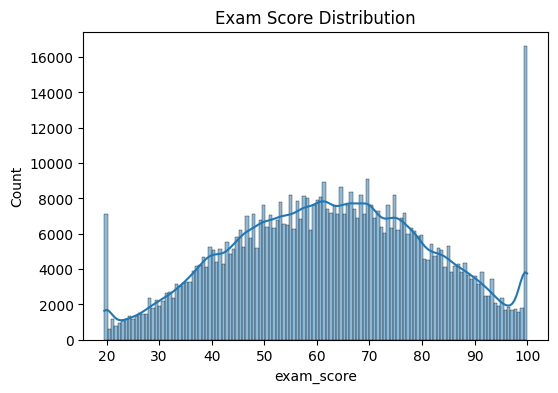

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(6,4))
sns.histplot(train["exam_score"], kde=True)
plt.title("Exam Score Distribution")
plt.show()


In [16]:

# La distribution des notes d’examen montre une forte concentration autour des valeurs
# intermédiaires(60–70), tandis que les scores très faibles et très élevés apparaissent moins
# fréquents. Cette répartition indique une population d’étudiants globalement centrée
# autour de la moyenne, avec quelques groupes situés aux extrêmes de la performance.

La distribution du score d’examen est unimodale et globalement continue, avec une concentration des observations autour de valeurs moyennes, et une accumulation aux bornes inférieure et supérieure, ce qui reste compatible avec une approche par modèles de régression.

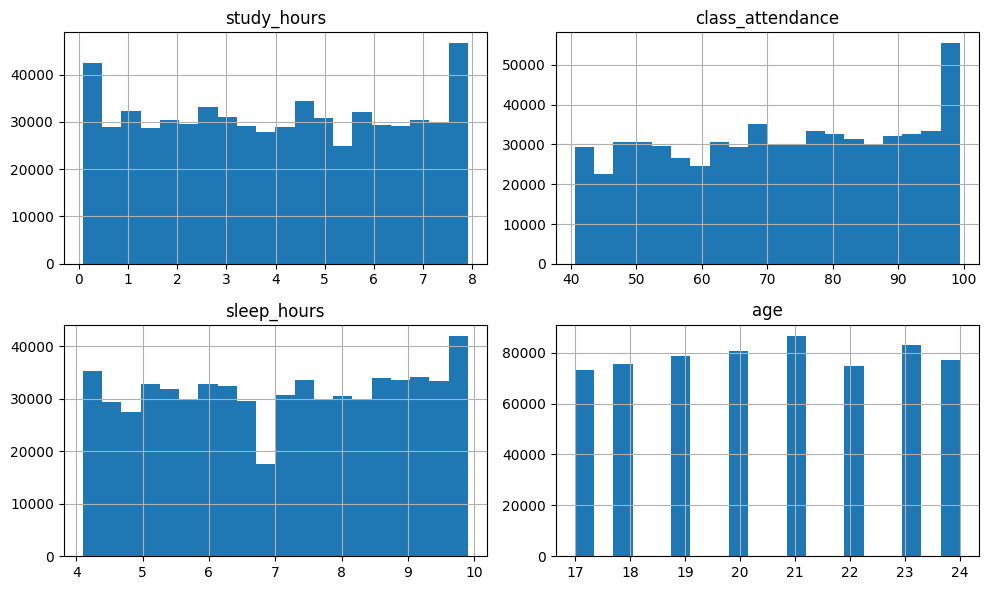

In [17]:
numeric_cols = ["study_hours", "class_attendance", "sleep_hours", "age"]

train[numeric_cols].hist(bins=20, figsize=(10,6))
plt.tight_layout()
plt.show()

In [18]:

# Les distributions montrent que les comportements des étudiants sont assez différents : les heures
# d’étude et de sommeil varient beaucoup d’une personne à l’autre, alors que l’assiduité en classe
# est plus souvent élevée. L’âge, lui, est réparti de manière assez régulière. Cette diversité dans
# leurs habitudes laisse penser que chaque étudiant suit son propre rythme, ce qui peut naturellement
# influencer leurs résultats à l’examen.

Les variables numériques présentent des distributions cohérentes et réalistes, sans valeurs aberrantes marquées, ce qui permet leur intégration directe dans les modèles de régression après standardisation.

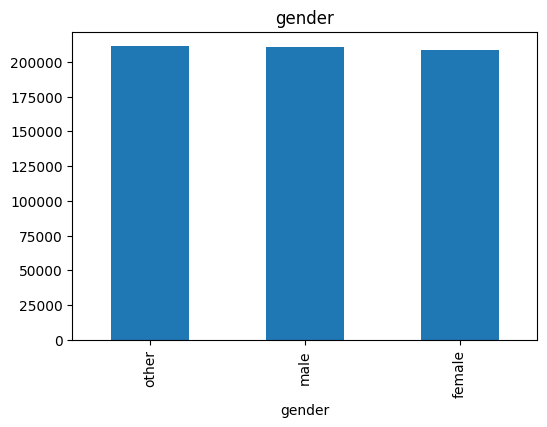

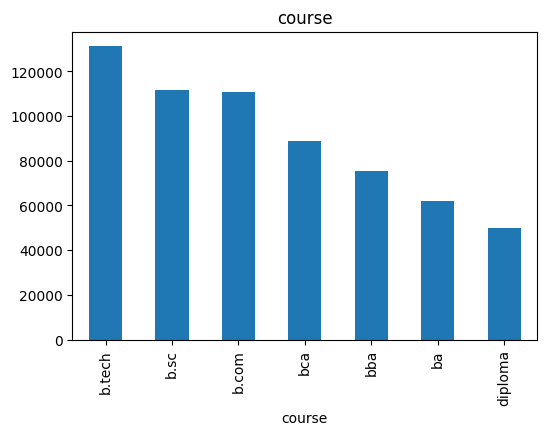

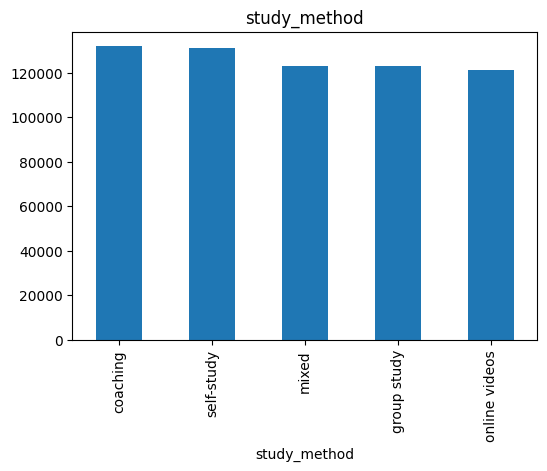

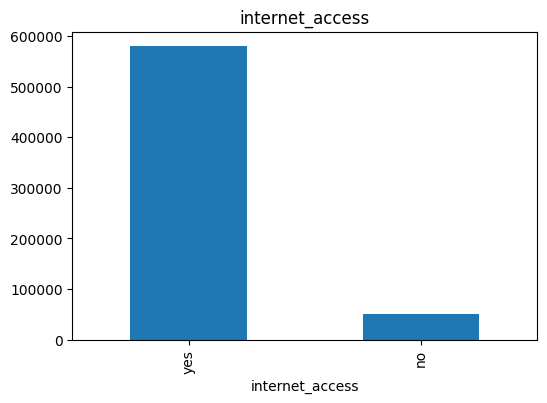

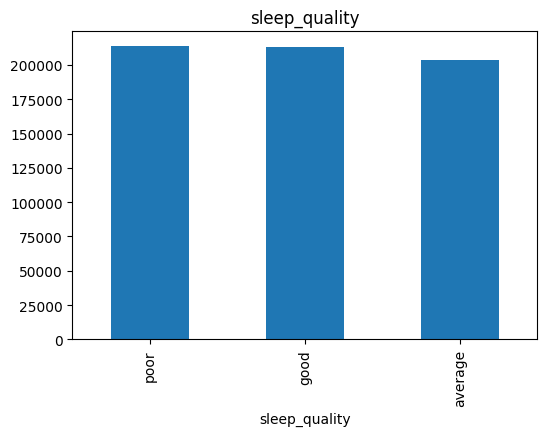

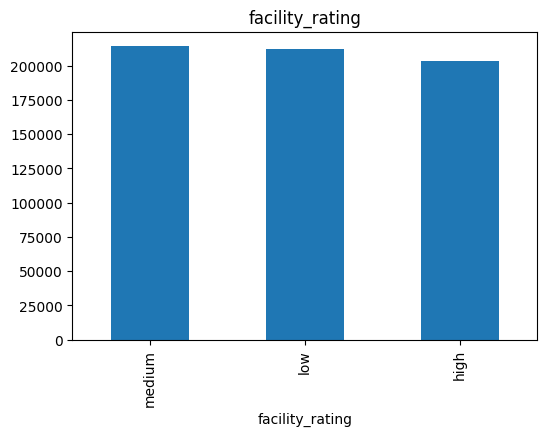

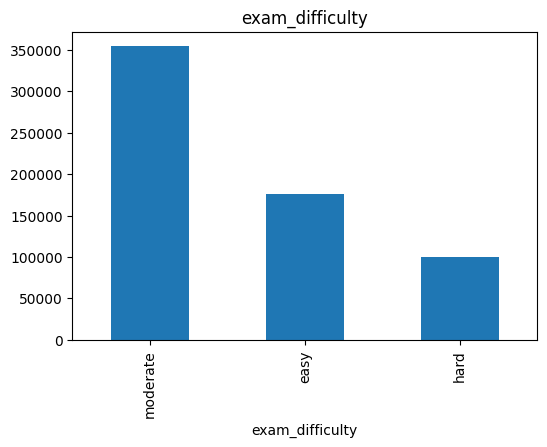

In [19]:
cat_cols = ["gender", "course", "study_method", "internet_access",
			"sleep_quality", "facility_rating", "exam_difficulty"]

for col in cat_cols:
	plt.figure(figsize=(6,4))
	train[col].value_counts().plot(kind="bar")
	plt.title(col)
	plt.show()

In [20]:

# Les variables catégorielles présentent des répartitions globalement équilibrées. Les méthodes
# d’étude sont utilisées dans des proportions proches, l’accès à Internet est majoritairement
# disponible, et les filières les plus fréquentes sont b.tech, b.sc et b.com. Les évaluations du
# sommeil, des installations et de la difficulté de l’examen restent également assez homogènes.
# Ces résultats indiquent une population étudiante variée mais sans déséquilibres importants.

Les variables catégorielles présentent des distributions globalement équilibrées, à l’exception de l’accès à Internet et de la difficulté de l’examen, dont les modalités sont inégalement représentées. Ces variables restent néanmoins pertinentes et peuvent être intégrées directement au modèle après un encodage approprié.

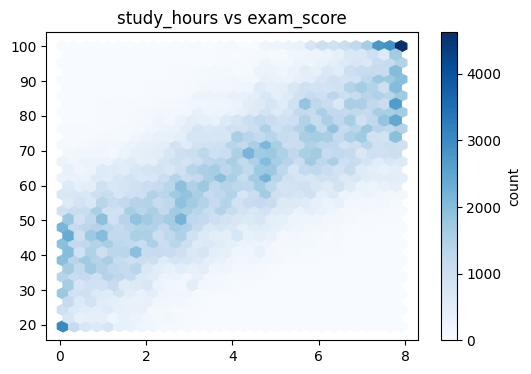

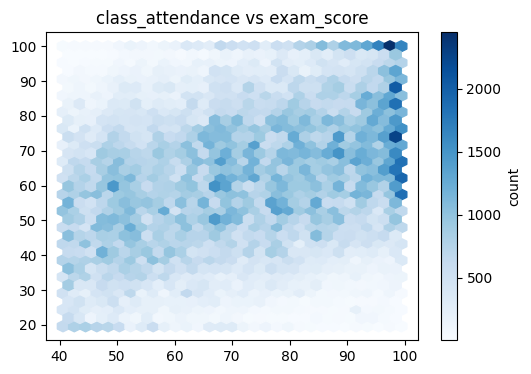

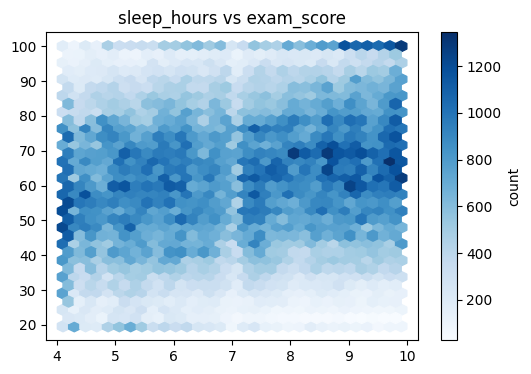

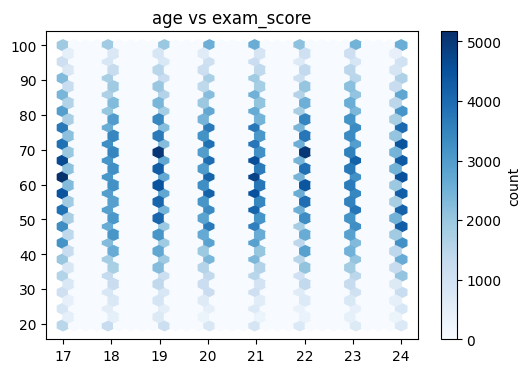

In [21]:
for col in numeric_cols:
	plt.figure(figsize=(6,4))
	plt.hexbin(train[col], train["exam_score"], gridsize=30, cmap="Blues")
	plt.colorbar(label="count")
	plt.title(f"{col} vs exam_score")
	plt.show()

In [22]:
# Les graphiques hexbin mettent en évidence les relations entre les variables
# numériques et le score d’examen. Une corrélation positive nette apparaît
# pour study_hours et class_attendance, suggérant un fort pouvoir prédictif.
# La relation avec sleep_hours est plus modérée, tandis que l’âge ne montre
# pas de tendance significative. Ces observations guideront l’analyse des
# performances des modèles de régression.


Les variables liées à l’investissement académique, notamment le temps d’étude et l’assiduité, présentent une corrélation positive avec le score d’examen, tandis que l’âge montre un impact limité. Le temps de sommeil semble avoir un effet potentiellement non linéaire.

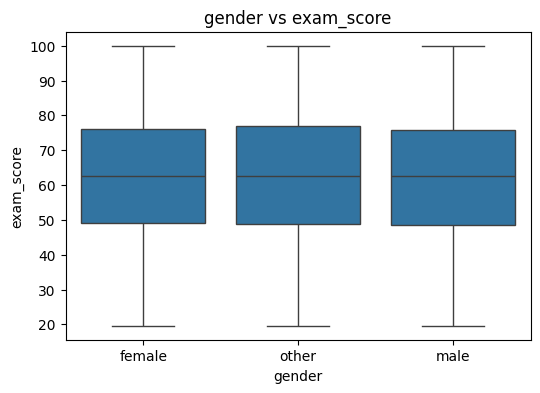

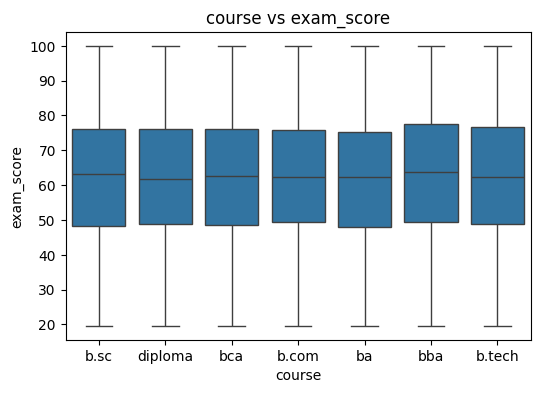

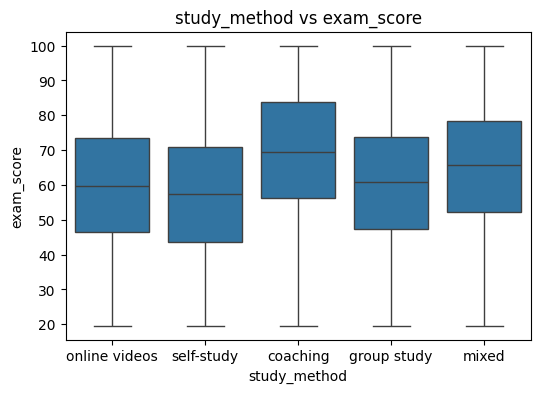

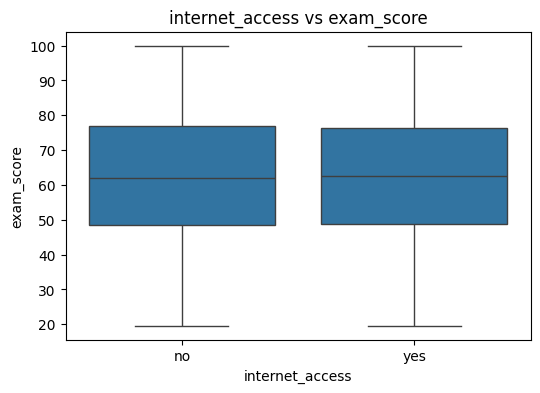

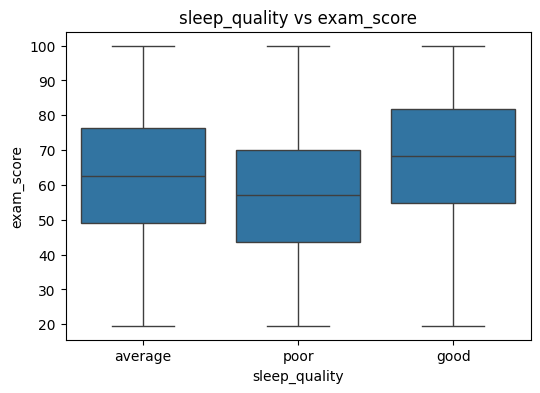

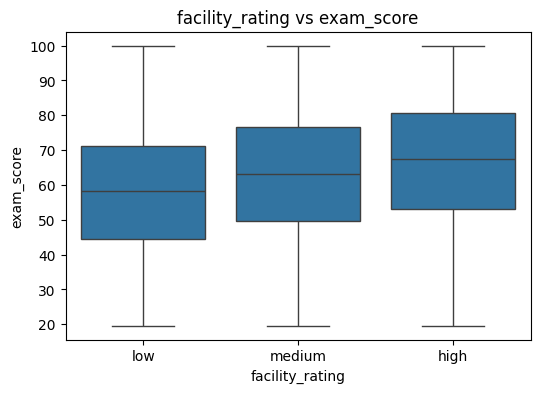

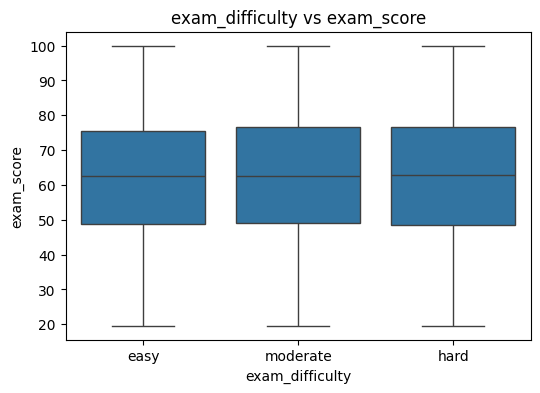

In [23]:
for col in cat_cols:
	plt.figure(figsize=(6,4))
	sns.boxplot(x=train[col], y=train["exam_score"])
	plt.title(f"{col} vs exam_score")
	plt.show()

In [ ]:
#Les boxplots montrent que les scores d’examen sont très proches entre les différentes catégories, 
# ce qui indique que ces variables n’ont pas un impact fort sur la performance.
#  On remarque seulement de petites différences pour la qualité du sommeil , facility-rating et study-method, où les scores sont légèrement plus élevés.

Les variables liées aux conditions et aux méthodes d’apprentissage, telles que la méthode d’étude, la qualité du sommeil et facility-rating, montrent des différences notables de performance. En revanche, le genre, l’âge, la filière et l’accès à Internet présentent des distributions de scores largement similaires entre leurs catégories.

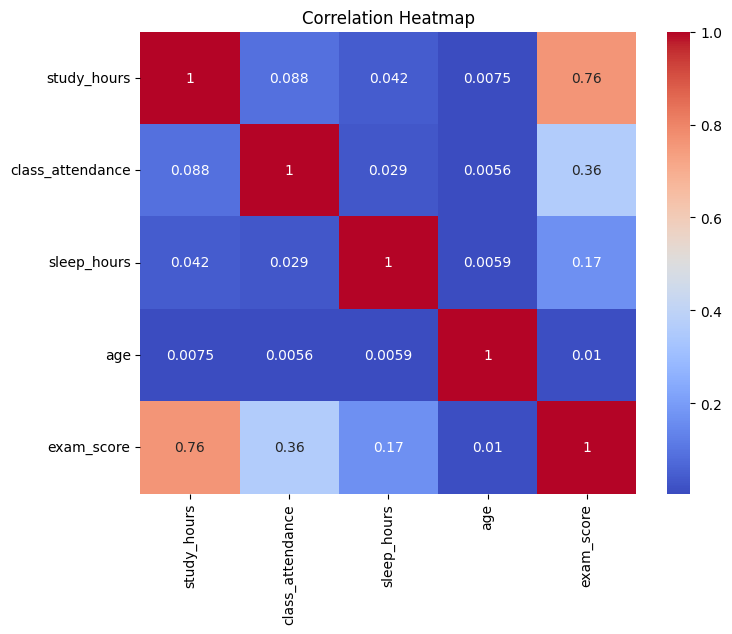

In [25]:
corr = train[numeric_cols + ["exam_score"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [26]:
# La matrice de corrélation confirme que le score d’examen est fortement
# corrélé aux heures d’étude (0.76), et dans une moindre mesure à l’assiduité
# en classe (0.36). Le sommeil présente un impact plus modéré, tandis que
# l’âge montre une corrélation négligeable. Les faibles corrélations entre
# variables explicatives indiquent l’absence de multicolinéarité importante,
# ce qui est favorable aux modèles de régression linéaire.


La matrice de corrélation met en évidence une forte corrélation positive entre le temps d’étude et le score d’examen (ρ ≈ 0,76), ainsi qu’une corrélation modérée avec l’assiduité. Les autres variables numériques présentent des corrélations faibles, et aucune colinéarité marquée n’est observée entre les variables explicatives.

In [27]:
# Corrélations de Pearson avec le score d’examen
numeric_cols = ["study_hours", "class_attendance", "sleep_hours", "age"]

corr = train[numeric_cols + ["exam_score"]].corr(method="pearson")
corr
corr["exam_score"].sort_values(ascending=False)


exam_score          1.000000
study_hours         0.762267
class_attendance    0.360954
sleep_hours         0.167410
age                 0.010472
Name: exam_score, dtype: float64

La variable la plus explicative du score à l’examen est le temps d’étude, suivie par la présence en cours. Le sommeil joue un rôle secondaire, tandis que l’âge apparaît négligeable pour la prédiction.

**Conclusion de l’analyse de corrélation**

L’analyse de corrélation de Pearson montre que study_hours est la variable la plus fortement associée au score à l’examen (r ≈ 0,76), indiquant une relation positive marquée entre le temps de travail personnel et la performance académique. Class_attendance présente une corrélation positive modérée (r ≈ 0,36), suggérant que l’assiduité en cours contribue également aux résultats, mais dans une moindre mesure. Sleep_hours affiche une corrélation faible (r ≈ 0,17), tandis que l’âge n’a pratiquement aucun lien avec le score (r ≈ 0,01). Ces résultats indiquent que les facteurs liés à l’engagement académique sont plus déterminants que les caractéristiques démographiques pour expliquer la performance aux examens.

In [28]:
# Séparation train / validation pour l’évaluation du modèle
from sklearn.model_selection import train_test_split

# Split pour évaluer le modèle (plan d'expérience)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print("Split terminé :")
print("X_tr :", X_tr.shape, "| y_tr :", y_tr.shape)
print("X_val:", X_val.shape, "| y_val:", y_val.shape)


Split terminé :
X_tr : (504000, 24) | y_tr : (504000,)
X_val: (126000, 24) | y_val: (126000,)


In [29]:
# Conversion en numérique (ignore les colonnes non numériques)
X_tr_numeric = X_tr.apply(pd.to_numeric, errors='coerce')
X_val_numeric = X_val.apply(pd.to_numeric, errors='coerce')

print("Inf dans X_tr :", np.isinf(X_tr_numeric).sum().sum())
print("Inf dans X_val :", np.isinf(X_val_numeric).sum().sum())

Inf dans X_tr : 0
Inf dans X_val : 0


In [30]:
from sklearn.feature_selection import VarianceThreshold

# Suppression des variables constantes (variance nulle)
selector = VarianceThreshold(threshold=0.0)

X_tr_clean = selector.fit_transform(X_tr)
X_val_clean = selector.transform(X_val)


In [31]:
#Après la séparation train/validation, l’absence de valeurs infinies et supprimé les variables constantes à l’aide d’un VarianceThreshold.
#  Cette étape garantit un jeu de données propre et exploitable pour l’apprentissage.
#  Les données sont désormais prêtes pour l’entraînement des modèles dans le plan d’expérience

C:\Users\imene\AppData\Local\Temp\ipykernel_10212\1861805287.py:33: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()


===== Régression Linéaire =====
MSE  : 78.970
RMSE : 8.886
R²   : 0.778


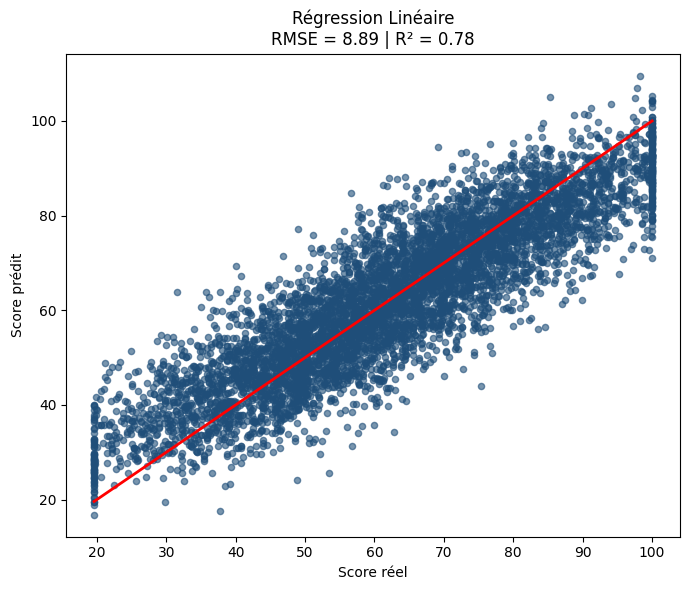


✅ Fichier CSV sauvegardé : submission_linear_regression.csv
📊 Stats : min=15.12, max=100.00, moy=62.50
       id  exam_score
0  630000   71.759754
1  630001   69.478246
2  630002   87.469780
3  630003   54.938523
4  630004   47.301788


In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# CHARGEMENT DES DONNÉES (comme dans ta 2ème fonction)
# ============================================================
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

y_train = train['exam_score']
X_train = train.drop(['exam_score', 'id'], axis=1)
X_test = test.drop('id', axis=1)        # ✅ X_test est défini ici
test_ids = test['id'].copy()             # ✅ test_ids est défini ici

# ============================================================
# SPLIT TRAIN/VALIDATION
# ============================================================
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# ============================================================
# PRÉPROCESSING (important pour la régression linéaire)
# ============================================================
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

# ============================================================
# PIPELINE DE RÉGRESSION LINÉAIRE
# ============================================================
from sklearn.pipeline import Pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Entraînement
lr_pipeline.fit(X_tr, y_tr)

# Prédictions sur validation
y_val_pred = lr_pipeline.predict(X_val)

# Métriques
mse_lr = mean_squared_error(y_val, y_val_pred)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_val, y_val_pred)

print("===== Régression Linéaire =====")
print(f"MSE  : {mse_lr:.3f}")
print(f"RMSE : {rmse_lr:.3f}")
print(f"R²   : {r2_lr:.3f}")

# ============================================================
# GRAPHIQUE (optionnel)
# ============================================================
sample_idx = np.random.choice(len(y_val), min(6000, len(y_val)), replace=False)
plt.figure(figsize=(7,6))
plt.scatter(
    y_val.iloc[sample_idx],
    y_val_pred[sample_idx],
    s=20, color="#1f4e79", alpha=0.6
)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], color="red", linewidth=2)
plt.xlabel("Score réel")
plt.ylabel("Score prédit")
plt.title(f"Régression Linéaire\nRMSE = {rmse_lr:.2f} | R² = {r2_lr:.2f}")
plt.tight_layout()
plt.show()

# ============================================================
# GÉNÉRATION DU FICHIER CSV POUR KAGGLE
# ============================================================
# Prédictions sur l'ensemble de test
y_test_pred = lr_pipeline.predict(X_test)
y_test_pred = np.clip(y_test_pred, 0, 100)  # Borner entre 0 et 100 comme dans ta 2ème fonction

# Création du DataFrame de submission
submission = pd.DataFrame({
    'id': test_ids,           # ✅ Colonne d'ID
    'exam_score': y_test_pred  # ✅ Colonne cible (exam_score)
})

# Sauvegarde en CSV
filename = 'submission_linear_regression.csv'
submission.to_csv(filename, index=False)
print(f"\n✅ Fichier CSV sauvegardé : {filename}")
print(f"📊 Stats : min={y_test_pred.min():.2f}, max={y_test_pred.max():.2f}, moy={y_test_pred.mean():.2f}")
print(submission.head())

In [33]:
#La régression linéaire obtient un RMSE de 8.887 et un R² de 0.778. 
# Cela signifie que le modèle explique environ 78% de la variance du score d’examen, 
# avec une erreur moyenne d’environ 9 points. Bien que les performances soient satisfaisantes pour un modèle linéaire simple,
#  une part non négligeable de la variance reste inexpliquée, ce qui justifie l’exploration de modèles plus complexes


📊 Dimensions: Train (630000, 11), Test (270000, 11)


C:\Users\imene\AppData\Local\Temp\ipykernel_10212\716538.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()



🏋️ Entraînement du Random Forest...

===== RANDOM FOREST OPTIMISÉ =====
RMSE : 9.001
MSE  : 81.022
R²   : 0.772


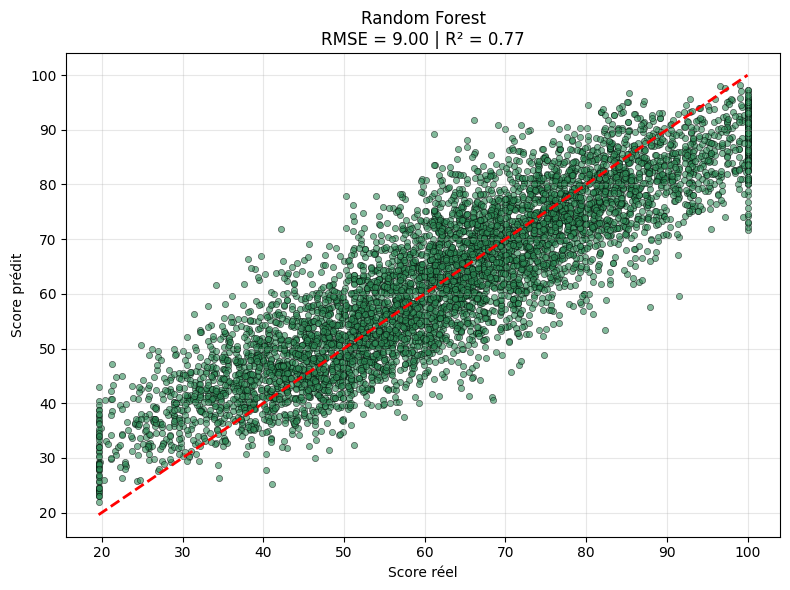


🔄 Prédictions sur l'ensemble de test...

✅ Fichier CSV sauvegardé : submission_random_forest.csv
📊 Stats : min=20.99, max=99.18, moy=62.51
       id  exam_score
0  630000   69.790834
1  630001   70.470722
2  630002   84.511021
3  630003   54.803627
4  630004   50.968339


In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# ============================================================
# CHARGEMENT DES DONNÉES
# ============================================================
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

y_train = train['exam_score']
X_train = train.drop(['exam_score', 'id'], axis=1)
X_test = test.drop('id', axis=1)
test_ids = test['id'].copy()

print(f"\n📊 Dimensions: Train {X_train.shape}, Test {X_test.shape}")

# ============================================================
# PRÉPROCESSING (obligatoire pour les variables catégorielles)
# ============================================================
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

# Transformer les données
X_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# ============================================================
# SPLIT TRAIN/VALIDATION
# ============================================================
X_tr, X_val, y_tr, y_val = train_test_split(
    X_processed, y_train, test_size=0.2, random_state=42
)

# ============================================================
# RANDOM FOREST (EXACTEMENT ta configuration)
# ============================================================
rf = RandomForestRegressor(
    n_estimators=600, 
    max_depth=30, 
    min_samples_split=5, 
    min_samples_leaf=2,
    max_features="sqrt", 
    n_jobs=-1,
    random_state=42
)

print("\n🏋️ Entraînement du Random Forest...")
rf.fit(X_tr, y_tr)

# Prédictions sur validation
y_val_pred_rf = rf.predict(X_val)

# Optionnel mais recommandé si score entre 0 et 100
y_val_pred_rf = np.clip(y_val_pred_rf, 0, 100)

# Calcul des métriques
mse_rf = mean_squared_error(y_val, y_val_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_val, y_val_pred_rf)

print("\n===== RANDOM FOREST OPTIMISÉ =====")
print(f"RMSE : {rmse_rf:.3f}")
print(f"MSE  : {mse_rf:.3f}")
print(f"R²   : {r2_rf:.3f}")

# ============================================================
# GRAPHIQUE SIMPLE (optionnel)
# ============================================================
sample_idx = np.random.choice(len(y_val), min(6000, len(y_val)), replace=False)

plt.figure(figsize=(8, 6))
plt.scatter(
    y_val.iloc[sample_idx],
    y_val_pred_rf[sample_idx],
    s=20, 
    color="#2E8B57",
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)

# Droite idéale
plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    color="red",
    linewidth=2,
    linestyle='--'
)

plt.xlabel("Score réel")
plt.ylabel("Score prédit")
plt.title(f"Random Forest\nRMSE = {rmse_rf:.2f} | R² = {r2_rf:.2f}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# GÉNÉRATION DU FICHIER CSV POUR KAGGLE
# ============================================================
print(f"\n🔄 Prédictions sur l'ensemble de test...")
y_test_pred_rf = rf.predict(X_test_processed)
y_test_pred_rf = np.clip(y_test_pred_rf, 0, 100)

# Création du DataFrame de submission
submission = pd.DataFrame({
    'id': test_ids,
    'exam_score': y_test_pred_rf
})

# Sauvegarde en CSV
filename = 'submission_random_forest.csv'
submission.to_csv(filename, index=False)
print(f"\n✅ Fichier CSV sauvegardé : {filename}")
print(f"📊 Stats : min={y_test_pred_rf.min():.2f}, max={y_test_pred_rf.max():.2f}, moy={y_test_pred_rf.mean():.2f}")
print(submission.head())

In [35]:
# Le Random Forest obtient un RMSE de 8.9, légèrement supérieur à celui de la régression linéaire (8.88). 
# Cela suggère que la structure des données est majoritairement linéaire et que
#l’ajout de complexité via un modèle d’ensemble n’améliore pas la performance prédictive.


📊 Dimensions: Train (630000, 11), Test (270000, 11)


C:\Users\imene\AppData\Local\Temp\ipykernel_10212\82478811.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()



🏋️ Entraînement du Gradient Boosting...

===== GRADIENT BOOSTING OPTIMISÉ =====
RMSE : 8.715
MSE  : 75.945
R²   : 0.786


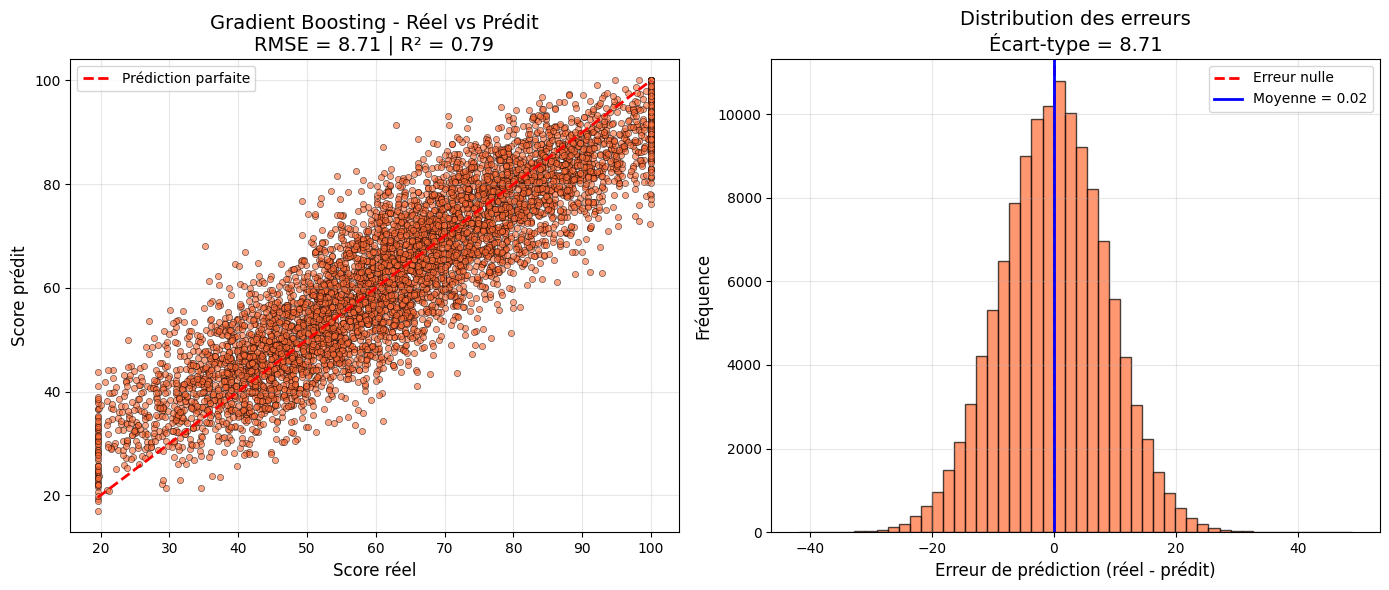

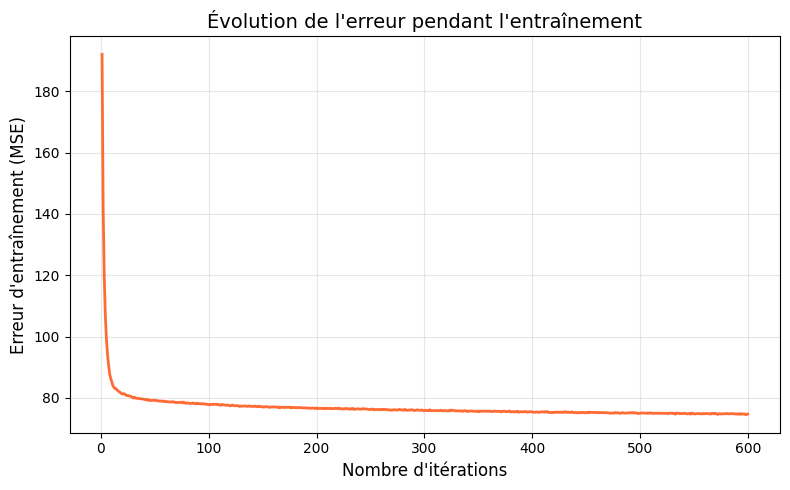


🌟 TOP 15 FEATURES LES PLUS IMPORTANTES
 1. study_hours                    : 0.7418
 2. class_attendance               : 0.1146
 3. study_method_coaching          : 0.0309
 4. sleep_quality_poor             : 0.0281
 5. sleep_hours                    : 0.0223
 6. sleep_quality_good             : 0.0198
 7. facility_rating_low            : 0.0168
 8. facility_rating_high           : 0.0142
 9. study_method_mixed             : 0.0042
10. study_method_self-study        : 0.0039
11. sleep_quality_average          : 0.0010
12. study_method_online videos     : 0.0008
13. facility_rating_medium         : 0.0005
14. age                            : 0.0004
15. study_method_group study       : 0.0001

🔄 Prédictions sur l'ensemble de test...

✅ Fichier CSV sauvegardé : submission_gradient_boosting.csv
📊 Stats des prédictions :
   - Min  : 11.87
   - Max  : 100.00
   - Moy  : 62.52
   - Médian: 62.87
   - Écart-type: 16.80

📋 Aperçu des 5 premières lignes:
       id  exam_score
0  630000   70.6884

In [36]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# ============================================================
# CHARGEMENT DES DONNÉES
# ============================================================
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

y_train = train['exam_score']
X_train = train.drop(['exam_score', 'id'], axis=1)
X_test = test.drop('id', axis=1)
test_ids = test['id'].copy()

print(f"\n📊 Dimensions: Train {X_train.shape}, Test {X_test.shape}")

# ============================================================
# PRÉPROCESSING (obligatoire pour les variables catégorielles)
# ============================================================
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

# Transformer les données
X_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# ============================================================
# SPLIT TRAIN/VALIDATION
# ============================================================
X_tr, X_val, y_tr, y_val = train_test_split(
    X_processed, y_train, test_size=0.2, random_state=42
)

# ============================================================
# GRADIENT BOOSTING (EXACTEMENT ta configuration)
# ============================================================
gbr = GradientBoostingRegressor(
    n_estimators=600,
    learning_rate=0.5,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

print("\n🏋️ Entraînement du Gradient Boosting...")
gbr.fit(X_tr, y_tr)

# Prédictions sur validation
y_val_pred = gbr.predict(X_val)

# Optionnel mais recommandé si score entre 0 et 100
y_val_pred = np.clip(y_val_pred, 0, 100)

# Calcul des métriques
mse_gbr = mean_squared_error(y_val, y_val_pred)
rmse_gbr = np.sqrt(mse_gbr)
r2_gbr = r2_score(y_val, y_val_pred)

print("\n===== GRADIENT BOOSTING OPTIMISÉ =====")
print(f"RMSE : {rmse_gbr:.3f}")
print(f"MSE  : {mse_gbr:.3f}")
print(f"R²   : {r2_gbr:.3f}")

# ============================================================
# GRAPHIQUE 1: VALEURS RÉELLES VS PRÉDITES
# ============================================================
sample_idx = np.random.choice(len(y_val), min(6000, len(y_val)), replace=False)

plt.figure(figsize=(14, 6))

# Graphique 1: Nuage de points
plt.subplot(1, 2, 1)
plt.scatter(
    y_val.iloc[sample_idx],
    y_val_pred[sample_idx],
    s=20, 
    color="#FF6B35",  # Orange vif
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)

# Droite idéale
plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    color="red",
    linewidth=2,
    linestyle='--',
    label='Prédiction parfaite'
)

plt.xlabel("Score réel", fontsize=12)
plt.ylabel("Score prédit", fontsize=12)
plt.title(f"Gradient Boosting - Réel vs Prédit\nRMSE = {rmse_gbr:.2f} | R² = {r2_gbr:.2f}", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Graphique 2: Distribution des erreurs
plt.subplot(1, 2, 2)
errors = y_val.values - y_val_pred
plt.hist(errors, bins=50, color="#FF6B35", edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Erreur nulle')
plt.axvline(x=np.mean(errors), color='blue', linestyle='-', linewidth=2, 
            label=f'Moyenne = {np.mean(errors):.2f}')

plt.xlabel("Erreur de prédiction (réel - prédit)", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)
plt.title(f"Distribution des erreurs\nÉcart-type = {np.std(errors):.2f}", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# GRAPHIQUE 2: ÉVOLUTION DE L'ERREUR PENDANT L'ENTRAÎNEMENT
# ============================================================
plt.figure(figsize=(8, 5))

# Récupérer l'historique des erreurs
train_score = gbr.train_score_
test_score = []  # Pourrait être calculé si on avait staged_predict

plt.plot(range(1, len(train_score) + 1), train_score, color="#FF6B35", linewidth=2)
plt.xlabel("Nombre d'itérations", fontsize=12)
plt.ylabel("Erreur d'entraînement (MSE)", fontsize=12)
plt.title("Évolution de l'erreur pendant l'entraînement", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# ANALYSE: IMPORTANCE DES FEATURES
# ============================================================
try:
    # Récupérer les noms des features après preprocessing
    feature_names = []
    
    # Features numériques
    feature_names.extend(numeric_cols)
    
    # Features catégorielles (après one-hot)
    cat_encoder = preprocessor.named_transformers_['cat']
    if hasattr(cat_encoder, 'get_feature_names_out'):
        cat_features = cat_encoder.get_feature_names_out(categorical_cols)
        feature_names.extend(cat_features)
    
    # Importance des features
    importances = gbr.feature_importances_
    
    # Trier par importance
    indices = np.argsort(importances)[::-1]
    
    # Afficher top 15 features
    print("\n" + "="*50)
    print("🌟 TOP 15 FEATURES LES PLUS IMPORTANTES")
    print("="*50)
    for i in range(min(15, len(feature_names))):
        print(f"{i+1:2d}. {feature_names[indices[i]]:30s} : {importances[indices[i]]:.4f}")
        
except Exception as e:
    print(f"\nNote: Impossible d'afficher l'importance des features ({e})")

# ============================================================
# GÉNÉRATION DU FICHIER CSV POUR KAGGLE
# ============================================================
print(f"\n🔄 Prédictions sur l'ensemble de test...")
y_test_pred = gbr.predict(X_test_processed)
y_test_pred = np.clip(y_test_pred, 0, 100)

# Création du DataFrame de submission
submission = pd.DataFrame({
    'id': test_ids,
    'exam_score': y_test_pred
})

# Sauvegarde en CSV
filename = 'submission_gradient_boosting.csv'
submission.to_csv(filename, index=False)
print(f"\n✅ Fichier CSV sauvegardé : {filename}")
print(f"📊 Stats des prédictions :")
print(f"   - Min  : {y_test_pred.min():.2f}")
print(f"   - Max  : {y_test_pred.max():.2f}")
print(f"   - Moy  : {y_test_pred.mean():.2f}")
print(f"   - Médian: {np.median(y_test_pred):.2f}")
print(f"   - Écart-type: {np.std(y_test_pred):.2f}")
print("\n📋 Aperçu des 5 premières lignes:")
print(submission.head())

# ============================================================
# COMPARAISON AVEC LES AUTRES MODÈLES (optionnel)
# ============================================================
print("\n" + "="*50)
print("📊 RÉCAPITULATIF DES MODÈLES")
print("="*50)
print(f"Gradient Boosting : RMSE = {rmse_gbr:.4f}")
# Tu pourrais ajouter les RMSE des autres modèles ici si tu les as

In [37]:
#Le Gradient Boosting obtient le meilleur RMSE (8.71), inférieur à celui de la régression linéaire (8.88). 
# Cela suggère que la structure des données présente une composante majoritairement linéaire, enrichie par de légères non-linéarités que le boosting parvient à capturer. 
# Toutefois, le gain reste modéré, indiquant que la complexité du problème est relativement faible.


📊 Dimensions: Train (630000, 11), Test (270000, 11)


C:\Users\imene\AppData\Local\Temp\ipykernel_10212\3447412565.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()



📊 Split: Train 504000 lignes, Val 126000 lignes

🏋️ ENTRAÎNEMENT DES 3 MODÈLES

▶️ Régression Linéaire...
   ✅ RMSE = 8.8813, R² = 0.7782

▶️ Random Forest...
   ✅ RMSE = 9.0021, R² = 0.7721

▶️ Gradient Boosting...
   ✅ RMSE = 8.7146, R² = 0.7865

🏆 CLASSEMENT FINAL
🥉 Gradient Boosting    : RMSE = 8.7146 | R² = 0.7865
🥇 Régression Linéaire  : RMSE = 8.8813 | R² = 0.7782
🥈 Random Forest        : RMSE = 9.0021 | R² = 0.7721


C:\Users\imene\AppData\Local\Temp\ipykernel_10212\3447412565.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(error_data, labels=model_names, patch_artist=True)
c:\Users\imene\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129353 (\N{THIRD PLACE MEDAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\imene\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\imene\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129352 (\N{SECOND PLACE MEDAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw

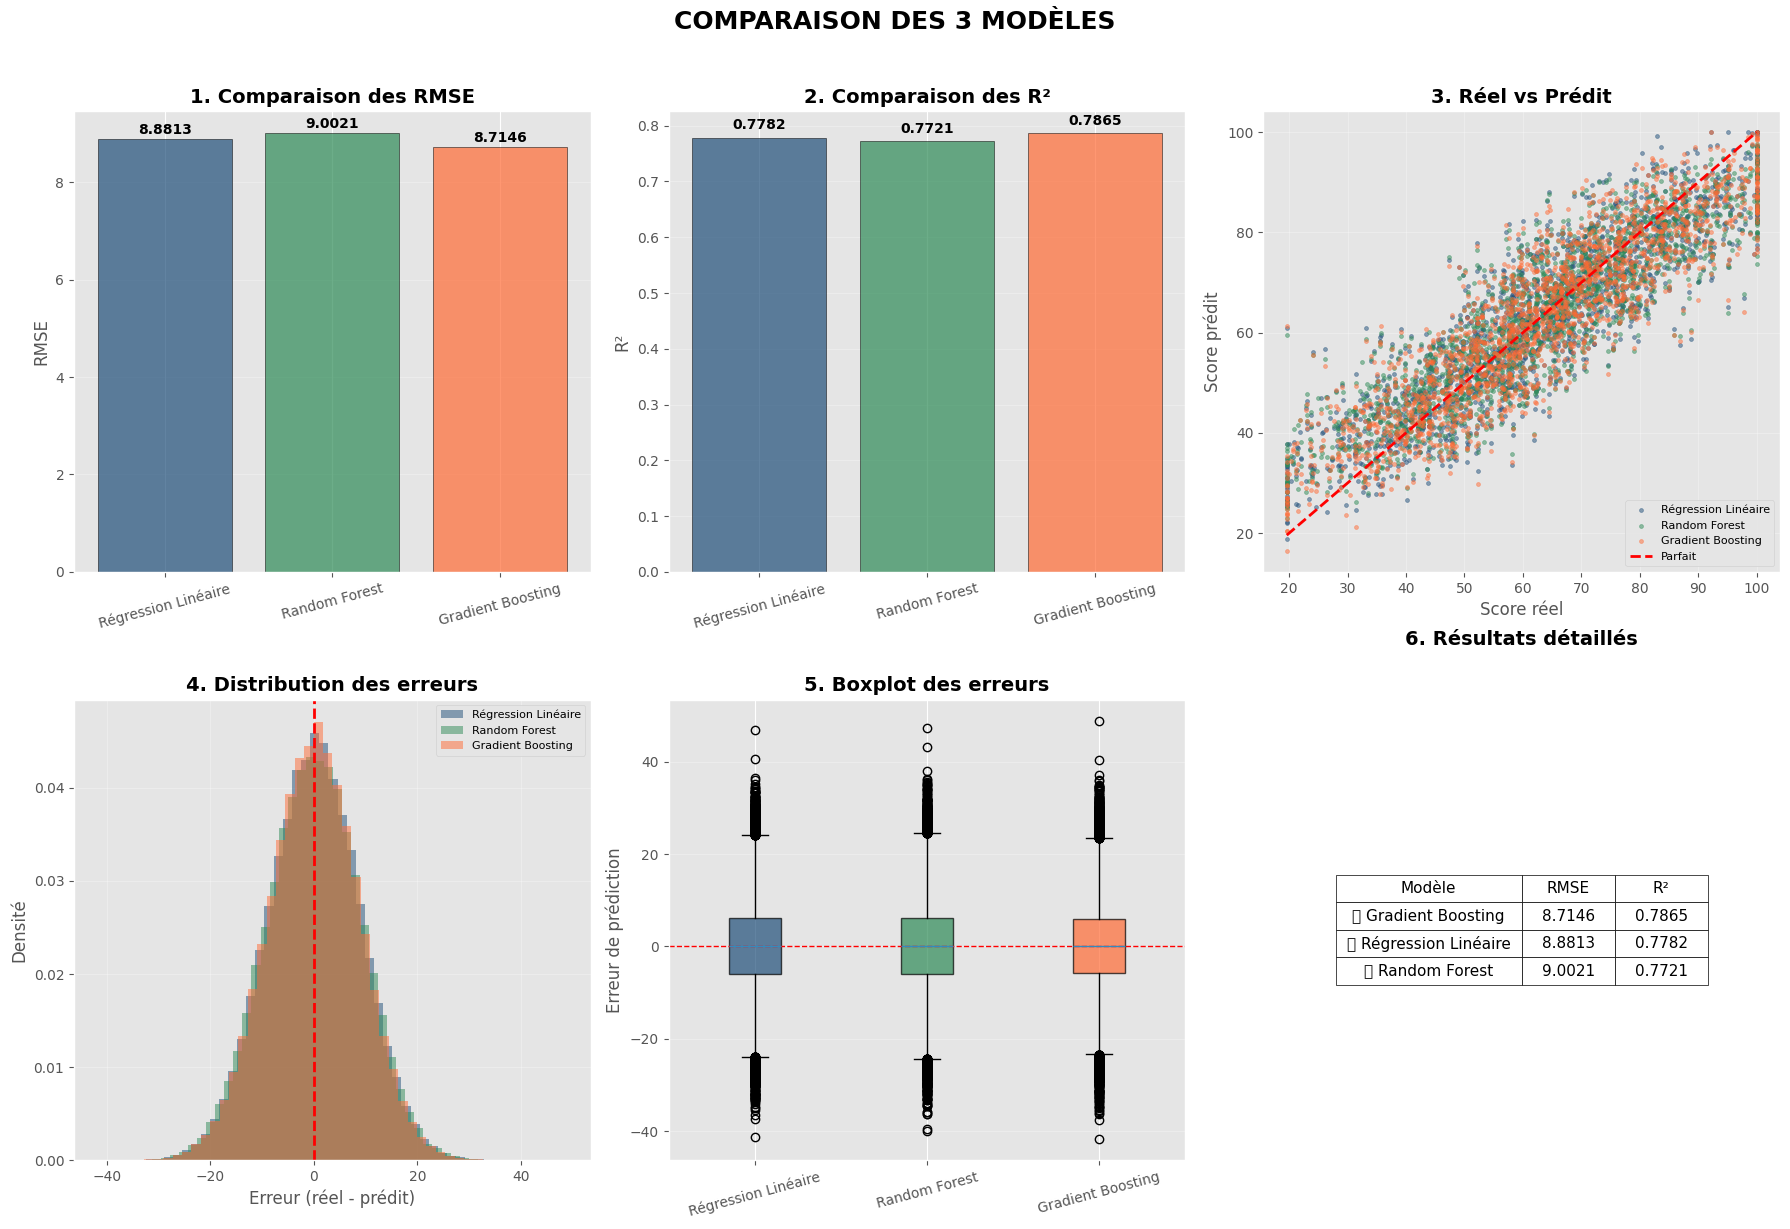


📁 GÉNÉRATION DES FICHIERS CSV POUR KAGGLE
✅ submission_regression_lineaire.csv  : RMSE val = 8.8813
✅ submission_random_forest.csv        : RMSE val = 9.0021
✅ submission_gradient_boosting.csv    : RMSE val = 8.7146

📊 ANALYSE DÉTAILLÉE

Régression Linéaire:
   RMSE: 8.8813
   Erreur moyenne: 0.0306
   Écart-type erreur: 8.8812
   % prédictions à ±5: 42.7%
   % prédictions à ±10: 73.9%

Random Forest:
   RMSE: 9.0021
   Erreur moyenne: 0.0401
   Écart-type erreur: 9.0020
   % prédictions à ±5: 41.7%
   % prédictions à ±10: 73.1%

Gradient Boosting:
   RMSE: 8.7146
   Erreur moyenne: 0.0198
   Écart-type erreur: 8.7146
   % prédictions à ±5: 43.5%
   % prédictions à ±10: 75.0%

🏆 MEILLEUR MODÈLE : Gradient Boosting avec RMSE = 8.7146


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ============================================================
# 1. CHARGEMENT DES DONNÉES
# ============================================================
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

y_train = train['exam_score']
X_train = train.drop(['exam_score', 'id'], axis=1)
X_test = test.drop('id', axis=1)
test_ids = test['id'].copy()

print(f"\n📊 Dimensions: Train {X_train.shape}, Test {X_test.shape}")

# ============================================================
# 2. PRÉPROCESSING
# ============================================================
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

# Transformer les données
X_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# ============================================================
# 3. SPLIT TRAIN/VALIDATION
# ============================================================
X_tr, X_val, y_tr, y_val = train_test_split(
    X_processed, y_train, test_size=0.2, random_state=42
)

print(f"\n📊 Split: Train {X_tr.shape[0]} lignes, Val {X_val.shape[0]} lignes")

# ============================================================
# 4. DÉFINITION DES 3 MODÈLES
# ============================================================
models = {
    'Régression Linéaire': LinearRegression(),
    
    'Random Forest': RandomForestRegressor(
        n_estimators=600,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ),
    
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=600,
        learning_rate=0.5,
        max_depth=3,
        subsample=0.8,
        random_state=42
    )
}

# ============================================================
# 5. ENTRAÎNEMENT ET COLLECTE DES RÉSULTATS
# ============================================================
results = []
predictions = {}
models_trained = {}

print("\n🏋️ ENTRAÎNEMENT DES 3 MODÈLES")
print("="*60)

for name, model in models.items():
    print(f"\n▶️ {name}...")
    
    # Entraînement
    model.fit(X_tr, y_tr)
    models_trained[name] = model
    
    # Prédictions sur validation
    y_pred = model.predict(X_val)
    y_pred = np.clip(y_pred, 0, 100)
    
    # Métriques
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    
    # Stockage
    results.append({
        'Modèle': name,
        'RMSE': rmse,
        'R²': r2
    })
    predictions[name] = y_pred
    
    print(f"   ✅ RMSE = {rmse:.4f}, R² = {r2:.4f}")

# ============================================================
# 6. TRI DES RÉSULTATS
# ============================================================
results_df = pd.DataFrame(results).sort_values('RMSE')
best_model = results_df.iloc[0]

print("\n" + "="*60)
print("🏆 CLASSEMENT FINAL")
print("="*60)
for idx, row in results_df.iterrows():
    medal = "🥇" if idx == 0 else "🥈" if idx == 1 else "🥉"
    print(f"{medal} {row['Modèle']:20s} : RMSE = {row['RMSE']:.4f} | R² = {row['R²']:.4f}")

# ============================================================
# 7. GRAPHIQUES DE COMPARAISON
# ============================================================
plt.style.use('ggplot')
fig = plt.figure(figsize=(18, 12))

# ------------------------------------------
# GRAPHIQUE 1: Barplot des RMSE
# ------------------------------------------
plt.subplot(2, 3, 1)
model_names = [r['Modèle'] for r in results]
rmse_values = [r['RMSE'] for r in results]
colors = ['#1f4e79', '#2E8B57', '#FF6B35']  # Bleu, Vert, Orange

bars = plt.bar(model_names, rmse_values, color=colors, alpha=0.7, edgecolor='black')
for bar, val in zip(bars, rmse_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.ylabel('RMSE', fontsize=12)
plt.title('1. Comparaison des RMSE', fontsize=14, fontweight='bold')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)

# ------------------------------------------
# GRAPHIQUE 2: Barplot des R²
# ------------------------------------------
plt.subplot(2, 3, 2)
r2_values = [r['R²'] for r in results]
bars = plt.bar(model_names, r2_values, color=colors, alpha=0.7, edgecolor='black')
for bar, val in zip(bars, r2_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.ylabel('R²', fontsize=12)
plt.title('2. Comparaison des R²', fontsize=14, fontweight='bold')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)

# ------------------------------------------
# GRAPHIQUE 3: Réel vs Prédit (tous modèles)
# ------------------------------------------
plt.subplot(2, 3, 3)
sample_idx = np.random.choice(len(y_val), min(2000, len(y_val)), replace=False)

for i, (name, y_pred) in enumerate(predictions.items()):
    plt.scatter(
        y_val.iloc[sample_idx], 
        y_pred[sample_idx], 
        alpha=0.5, 
        s=8, 
        color=colors[i],
        label=f'{name}'
    )

plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 
         'r--', linewidth=2, label='Parfait')

plt.xlabel('Score réel')
plt.ylabel('Score prédit')
plt.title('3. Réel vs Prédit', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=8)
plt.grid(True, alpha=0.3)

# ------------------------------------------
# GRAPHIQUE 4: Distribution des erreurs
# ------------------------------------------
plt.subplot(2, 3, 4)

for i, (name, y_pred) in enumerate(predictions.items()):
    errors = y_val.values - y_pred
    plt.hist(errors, bins=50, alpha=0.5, color=colors[i], 
             label=f'{name}', density=True)

plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Erreur (réel - prédit)')
plt.ylabel('Densité')
plt.title('4. Distribution des erreurs', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=8)
plt.grid(True, alpha=0.3)

# ------------------------------------------
# GRAPHIQUE 5: Boxplot des erreurs
# ------------------------------------------
plt.subplot(2, 3, 5)

error_data = [y_val.values - predictions[name] for name in model_names]
bp = plt.boxplot(error_data, labels=model_names, patch_artist=True)

for i, box in enumerate(bp['boxes']):
    box.set_facecolor(colors[i])
    box.set_alpha(0.7)

plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.ylabel('Erreur de prédiction')
plt.title('5. Boxplot des erreurs', fontsize=14, fontweight='bold')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)

# ------------------------------------------
# GRAPHIQUE 6: Tableau des résultats
# ------------------------------------------
plt.subplot(2, 3, 6)
plt.axis('tight')
plt.axis('off')

# Créer un tableau avec les résultats
cell_text = []
for idx, row in results_df.iterrows():
    medal = "🥇" if idx == 0 else "🥈" if idx == 1 else "🥉"
    cell_text.append([
        f"{medal} {row['Modèle']}", 
        f"{row['RMSE']:.4f}", 
        f"{row['R²']:.4f}"
    ])

table = plt.table(cellText=cell_text, 
                  colLabels=['Modèle', 'RMSE', 'R²'],
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.3, 0.15, 0.15])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)

plt.title('6. Résultats détaillés', fontsize=14, fontweight='bold', y=1.1)

plt.suptitle('COMPARAISON DES 3 MODÈLES', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# 8. GÉNÉRATION DES FICHIERS CSV
# ============================================================
print("\n" + "="*60)
print("📁 GÉNÉRATION DES FICHIERS CSV POUR KAGGLE")
print("="*60)

for name, model in models_trained.items():
    # Prédictions sur test
    y_test_pred = model.predict(X_test_processed)
    y_test_pred = np.clip(y_test_pred, 0, 100)
    
    # Nom de fichier propre
    filename = f'submission_{name.lower().replace(" ", "_").replace("é", "e")}.csv'
    
    # Création du DataFrame
    submission = pd.DataFrame({
        'id': test_ids,
        'exam_score': y_test_pred
    })
    
    # Sauvegarde
    submission.to_csv(filename, index=False)
    
    # Récupérer le RMSE correspondant
    rmse_val = results[[r['Modèle'] for r in results].index(name)]['RMSE']
    print(f"✅ {filename:35s} : RMSE val = {rmse_val:.4f}")

# ============================================================
# 9. ANALYSE DÉTAILLÉE
# ============================================================
print("\n" + "="*60)
print("📊 ANALYSE DÉTAILLÉE")
print("="*60)

for name, y_pred in predictions.items():
    rmse = results[[r['Modèle'] for r in results].index(name)]['RMSE']
    errors = y_val.values - y_pred
    
    print(f"\n{name}:")
    print(f"   RMSE: {rmse:.4f}")
    print(f"   Erreur moyenne: {np.mean(errors):.4f}")
    print(f"   Écart-type erreur: {np.std(errors):.4f}")
    print(f"   % prédictions à ±5: {np.mean(np.abs(errors) <= 5) * 100:.1f}%")
    print(f"   % prédictions à ±10: {np.mean(np.abs(errors) <= 10) * 100:.1f}%")

print("\n" + "="*60)
print(f"🏆 MEILLEUR MODÈLE : {best_model['Modèle']} avec RMSE = {best_model['RMSE']:.4f}")
print("="*60)

In [39]:
#Le Gradient Boosting obtient la meilleure performance (RMSE = 8.71), suivi de très près par la régression linéaire (RMSE = 8.88).
#La faible différence entre les modèles suggère que la relation entre les variables explicatives et le score d’examen est majoritairement linéaire.


📊 Dimensions: Train (630000, 12), Test (270000, 12)

🔧 Feature Engineering...
✅ Nouvelles features ajoutées: 'study_x_att', 'sleep_dev2'
📊 Nouvelles dimensions après feature engineering: (630000, 13)

📊 Split: Train 504000 lignes, Val 126000 lignes

🔍 Types de colonnes:
   - Numériques: 6 colonnes
   - Catégorielles: 7 colonnes

🔍 Recherche du meilleur alpha...
   - Grille: 20 valeurs de 0.0010 à 1000.0

🏋️ Entraînement avec GridSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


C:\Users\imene\AppData\Local\Temp\ipykernel_10212\1864572217.py:63: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_tr.select_dtypes(include="object").columns.tolist()



✅ Meilleur alpha trouvé: 0.3360
✅ Meilleur score CV (MSE): 79.1310

===== RIDGE RÉGRESSION OPTIMISÉE =====
RMSE (validation): 8.8813
MSE  (validation): 78.8773
R²   (validation): 0.7782
Alpha optimal     : 0.3360


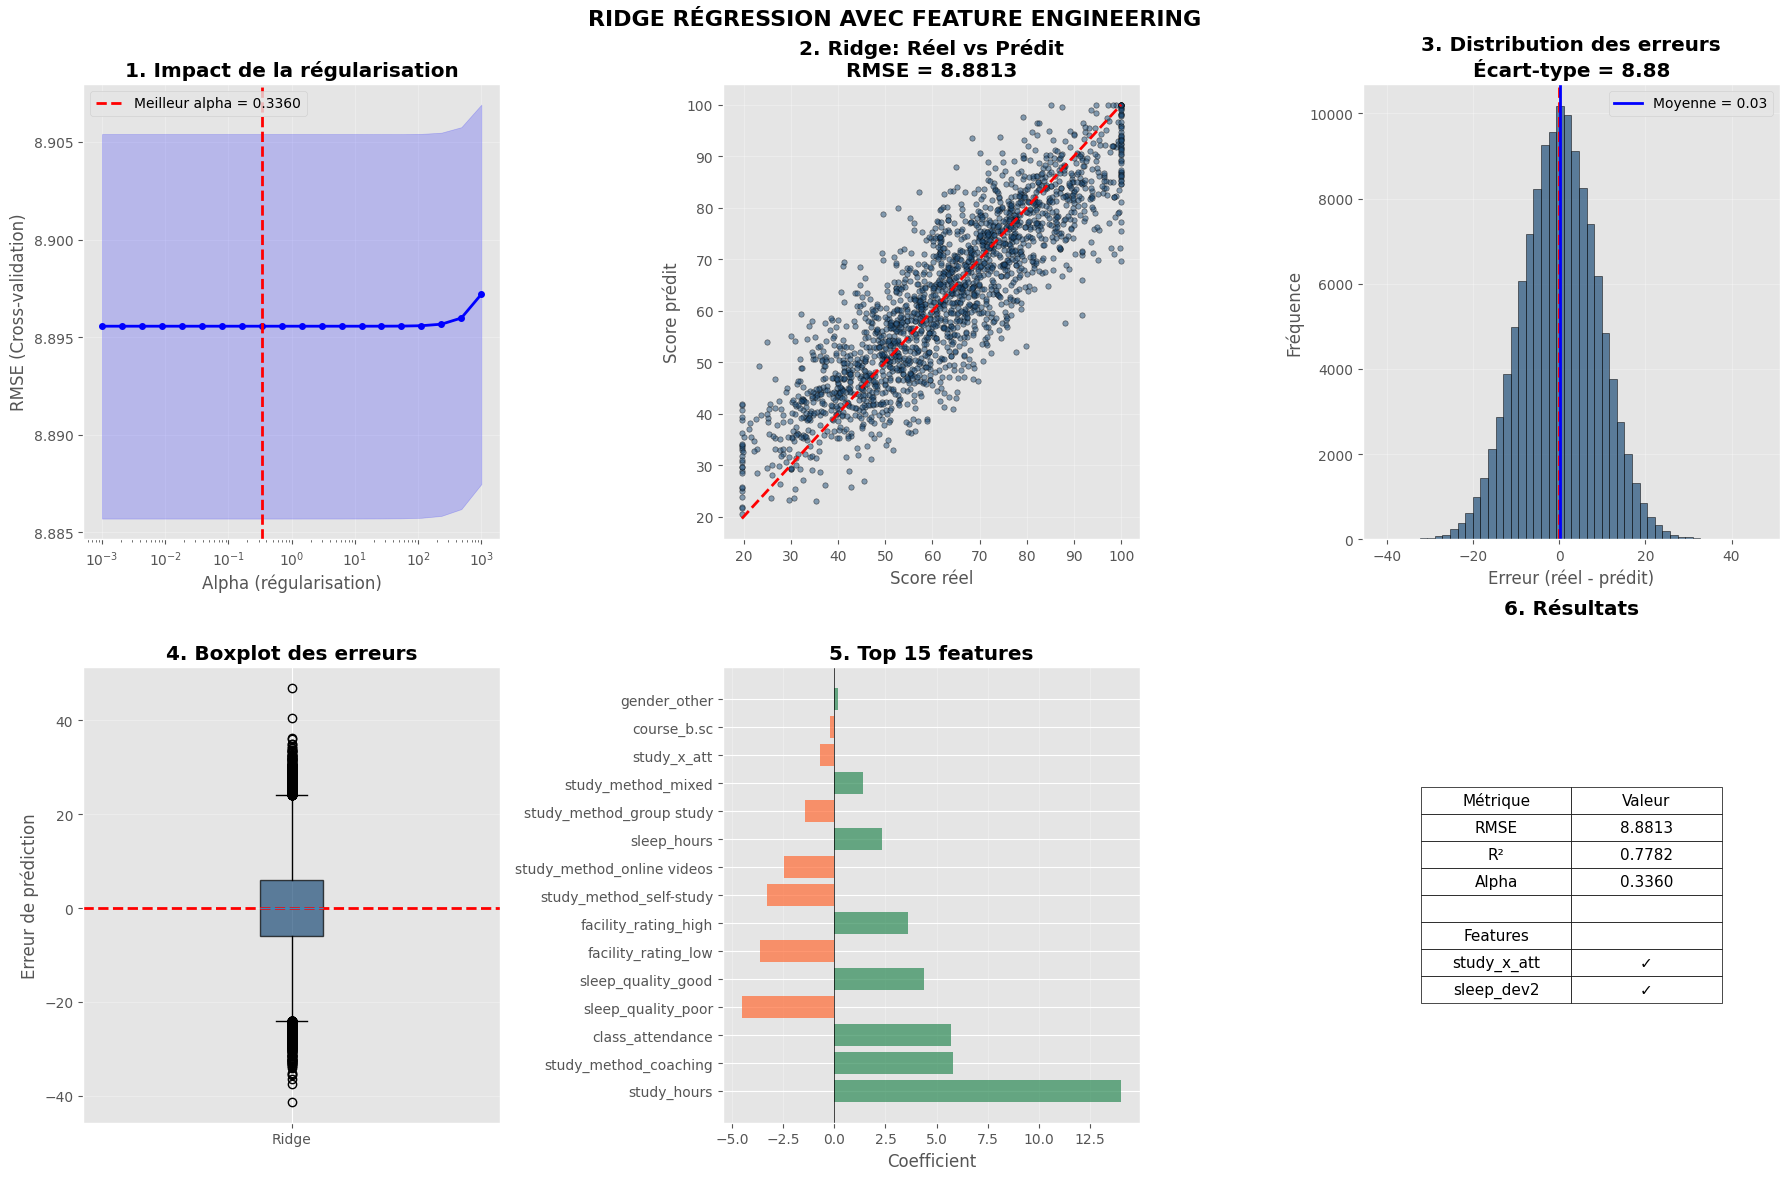


📁 GÉNÉRATION DU FICHIER CSV POUR KAGGLE

🔄 Prédictions sur l'ensemble de test...
   - X_test shape: (270000, 13)
   - Colonnes: ['age', 'gender', 'course', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty', 'study_x_att', 'sleep_dev2']

✅ Fichier CSV sauvegardé : submission_ridge_optimized.csv

📊 STATISTIQUES DES PRÉDICTIONS:
   - Min : 14.67
   - Max : 100.00
   - Moy : 62.50

📋 APERÇU DES 5 PREMIÈRES LIGNES:
       id  exam_score
0  630000   71.842655
1  630001   69.741776
2  630002   87.232053
3  630003   54.941753
4  630004   47.089162

✅ RIDGE RÉGRESSION TERMINÉE AVEC SUCCÈS !


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# ============================================================
# 1. CHARGEMENT DES DONNÉES
# ============================================================
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

y = train["exam_score"]
X = train.drop("exam_score", axis=1)  # On enlève exam_score mais on garde id pour l'instant
X_test = test.copy()  # On garde id pour l'instant
test_ids = test['id'].copy()

print(f"\n📊 Dimensions: Train {X.shape}, Test {X_test.shape}")

# ============================================================
# 2. CRÉATION DE NOUVELLES FEATURES (Feature Engineering)
# ============================================================
print("\n🔧 Feature Engineering...")
X = X.copy()
X_test = X_test.copy()

# Interaction study_hours × class_attendance
X["study_x_att"] = X["study_hours"] * X["class_attendance"]
X_test["study_x_att"] = X_test["study_hours"] * X_test["class_attendance"]

# Déviation carrée de sleep_hours par rapport à 7h (optimum supposé)
X["sleep_dev2"] = (X["sleep_hours"] - 7.0) ** 2
X_test["sleep_dev2"] = (X_test["sleep_hours"] - 7.0) ** 2

print(f"✅ Nouvelles features ajoutées: 'study_x_att', 'sleep_dev2'")

# ============================================================
# 3. SUPPRIMER L'ID MAINTENANT (après feature engineering)
# ============================================================
X = X.drop('id', axis=1)
X_test = X_test.drop('id', axis=1)  # ✅ On enlève id ICI, après avoir créé les features

print(f"📊 Nouvelles dimensions après feature engineering: {X.shape}")

# ============================================================
# 4. SPLIT TRAIN/VALIDATION
# ============================================================
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n📊 Split: Train {X_tr.shape[0]} lignes, Val {X_val.shape[0]} lignes")

# ============================================================
# 5. PRÉPROCESSING
# ============================================================
numeric_cols = X_tr.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_tr.select_dtypes(include="object").columns.tolist()

print(f"\n🔍 Types de colonnes:")
print(f"   - Numériques: {len(numeric_cols)} colonnes")
print(f"   - Catégorielles: {len(cat_cols)} colonnes")

preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
])

# ============================================================
# 6. PIPELINE RIDGE AVEC GRID SEARCH
# ============================================================
ridge_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("ridge", Ridge())
])

# Grille d'hyperparamètres pour alpha
param_grid = {"ridge__alpha": np.logspace(-3, 3, 20)}

print("\n🔍 Recherche du meilleur alpha...")
print(f"   - Grille: {len(param_grid['ridge__alpha'])} valeurs de {param_grid['ridge__alpha'][0]:.4f} à {param_grid['ridge__alpha'][-1]:.1f}")

grid = GridSearchCV(
    ridge_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

# ============================================================
# 7. ENTRAÎNEMENT
# ============================================================
print("\n🏋️ Entraînement avec GridSearchCV...")
grid.fit(X_tr, y_tr)

best_model = grid.best_estimator_
best_alpha = grid.best_params_["ridge__alpha"]
best_score = -grid.best_score_

print(f"\n✅ Meilleur alpha trouvé: {best_alpha:.4f}")
print(f"✅ Meilleur score CV (MSE): {best_score:.4f}")

# ============================================================
# 8. ÉVALUATION SUR VALIDATION
# ============================================================
y_val_pred = best_model.predict(X_val)
y_val_pred = np.clip(y_val_pred, 0, 100)

# Métriques
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2_val = r2_score(y_val, y_val_pred)
mse_val = mean_squared_error(y_val, y_val_pred)

print("\n===== RIDGE RÉGRESSION OPTIMISÉE =====")
print(f"RMSE (validation): {rmse_val:.4f}")
print(f"MSE  (validation): {mse_val:.4f}")
print(f"R²   (validation): {r2_val:.4f}")
print(f"Alpha optimal     : {best_alpha:.4f}")

# ============================================================
# 9. GRAPHIQUES
# ============================================================
plt.style.use('ggplot')
fig = plt.figure(figsize=(18, 12))

# GRAPHIQUE 1: Évolution du RMSE en fonction d'alpha
plt.subplot(2, 3, 1)
cv_results = pd.DataFrame(grid.cv_results_)
alphas = cv_results['param_ridge__alpha'].values
mean_test_scores = -cv_results['mean_test_score']
std_test_scores = cv_results['std_test_score']

plt.semilogx(alphas, np.sqrt(mean_test_scores), 'b-', linewidth=2, marker='o', markersize=4)
plt.fill_between(alphas, 
                 np.sqrt(mean_test_scores - std_test_scores), 
                 np.sqrt(mean_test_scores + std_test_scores), 
                 alpha=0.2, color='blue')
plt.axvline(x=best_alpha, color='red', linestyle='--', linewidth=2, label=f'Meilleur alpha = {best_alpha:.4f}')
plt.xlabel('Alpha (régularisation)')
plt.ylabel('RMSE (Cross-validation)')
plt.title('1. Impact de la régularisation', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# GRAPHIQUE 2: Réel vs Prédit
plt.subplot(2, 3, 2)
sample_idx = np.random.choice(len(y_val), min(2000, len(y_val)), replace=False)
plt.scatter(y_val.iloc[sample_idx], y_val_pred[sample_idx], s=15, color='#1f4e79', alpha=0.5, edgecolors='black')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', linewidth=2)
plt.xlabel('Score réel')
plt.ylabel('Score prédit')
plt.title(f'2. Ridge: Réel vs Prédit\nRMSE = {rmse_val:.4f}', fontweight='bold')
plt.grid(True, alpha=0.3)

# GRAPHIQUE 3: Distribution des erreurs
plt.subplot(2, 3, 3)
errors = y_val.values - y_val_pred
plt.hist(errors, bins=50, color='#1f4e79', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.axvline(x=np.mean(errors), color='blue', linestyle='-', linewidth=2, label=f'Moyenne = {np.mean(errors):.2f}')
plt.xlabel('Erreur (réel - prédit)')
plt.ylabel('Fréquence')
plt.title(f'3. Distribution des erreurs\nÉcart-type = {np.std(errors):.2f}', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# GRAPHIQUE 4: Boxplot des erreurs
plt.subplot(2, 3, 4)
plt.boxplot(errors, vert=True, patch_artist=True, boxprops=dict(facecolor='#1f4e79', alpha=0.7))
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.ylabel('Erreur de prédiction')
plt.xticks([1], ['Ridge'])
plt.title('4. Boxplot des erreurs', fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# GRAPHIQUE 5: Importance des features
plt.subplot(2, 3, 5)
ridge_model = best_model.named_steps['ridge']
preprocessor = best_model.named_steps['preprocess']

# Obtenir les noms des features
feature_names = numeric_cols.copy()
cat_encoder = preprocessor.named_transformers_['cat']
if hasattr(cat_encoder, 'get_feature_names_out'):
    cat_features = cat_encoder.get_feature_names_out(cat_cols)
    feature_names.extend(cat_features)

coefficients = ridge_model.coef_
coef_importance = np.abs(coefficients)
indices = np.argsort(coef_importance)[::-1]

top_n = min(15, len(feature_names))
top_indices = indices[:top_n]
top_features = [feature_names[i] for i in top_indices]
top_coefs = coefficients[top_indices]

colors = ['#2E8B57' if c > 0 else '#FF6B35' for c in top_coefs]
plt.barh(range(top_n), top_coefs, color=colors, alpha=0.7)
plt.yticks(range(top_n), top_features)
plt.xlabel('Coefficient')
plt.title('5. Top 15 features', fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', alpha=0.3)

# GRAPHIQUE 6: Tableau des métriques
plt.subplot(2, 3, 6)
plt.axis('tight')
plt.axis('off')
cell_text = [
    ['Métrique', 'Valeur'],
    ['RMSE', f'{rmse_val:.4f}'],
    ['R²', f'{r2_val:.4f}'],
    ['Alpha', f'{best_alpha:.4f}'],
    ['', ''],
    ['Features', ''],
    ['study_x_att', '✓'],
    ['sleep_dev2', '✓']
]
table = plt.table(cellText=cell_text, cellLoc='center', loc='center', colWidths=[0.3, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)
plt.title('6. Résultats', fontweight='bold', y=1.1)

plt.suptitle('RIDGE RÉGRESSION AVEC FEATURE ENGINEERING', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# 10. GÉNÉRATION DU FICHIER CSV POUR KAGGLE (CORRIGÉ)
# ============================================================
print("\n" + "="*60)
print("📁 GÉNÉRATION DU FICHIER CSV POUR KAGGLE")
print("="*60)

# Prédictions sur l'ensemble de test
print("\n🔄 Prédictions sur l'ensemble de test...")

# ✅ ICI, X_test n'a PAS de colonne 'id' (on l'a enlevée plus tôt)
print(f"   - X_test shape: {X_test.shape}")
print(f"   - Colonnes: {list(X_test.columns)}")

y_test_pred = best_model.predict(X_test)
y_test_pred = np.clip(y_test_pred, 0, 100)

# Création du DataFrame de submission avec les IDs
submission = pd.DataFrame({
    'id': test_ids,  # On utilise les IDs sauvegardés
    'exam_score': y_test_pred
})

# Sauvegarde en CSV
filename = 'submission_ridge_optimized.csv'
submission.to_csv(filename, index=False)

print(f"\n✅ Fichier CSV sauvegardé : {filename}")
print(f"\n📊 STATISTIQUES DES PRÉDICTIONS:")
print(f"   - Min : {y_test_pred.min():.2f}")
print(f"   - Max : {y_test_pred.max():.2f}")
print(f"   - Moy : {y_test_pred.mean():.2f}")

print("\n📋 APERÇU DES 5 PREMIÈRES LIGNES:")
print(submission.head())

print("\n" + "="*60)
print("✅ RIDGE RÉGRESSION TERMINÉE AVEC SUCCÈS !")
print("="*60)

In [41]:
#La Ridge Regression n’améliore pas les performances par rapport à la régression linéaire classique (RMSE identique ≈ 8.88). 
# Cela indique que le jeu de données ne présente pas de multicolinéarité problématique et que 
# la relation entre les variables explicatives et le score d’examen est essentiellement linéaire


📊 Dimensions: Train (630000, 12), Test (270000, 12)

🔧 Feature Engineering...
✅ Feature 'study_x_att' ajoutée
✅ Feature 'sleep_dev2' ajoutée
📊 Dimensions après feature engineering: (630000, 13)

📊 Split: Train 504000 lignes, Val 126000 lignes

🔍 Types de colonnes:
   - Numériques: 6 colonnes
   - Catégorielles: 7 colonnes

🔍 Recherche du meilleur alpha...
   - Grille: 20 valeurs de 0.0001 à 10.0

🏋️ Entraînement avec GridSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


C:\Users\imene\AppData\Local\Temp\ipykernel_10212\3208444081.py:65: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_tr.select_dtypes(include="object").columns.tolist()



✅ Meilleur alpha trouvé: 0.000336
✅ Meilleur score CV (MSE): 79.1309

===== LASSO RÉGRESSION OPTIMISÉE =====
RMSE (validation): 8.8812
MSE  (validation): 78.8766
R²   (validation): 0.7782
Alpha optimal     : 0.000336

📊 ANALYSE DE SPARSITÉ:
   - Coefficients totaux: 32
   - Coefficients nuls (≈0): 6
   - Sparsité: 18.8%


C:\Users\imene\AppData\Local\Temp\ipykernel_10212\3208444081.py:161: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  plt.semilogx(alphas, np.sqrt(mean_test_scores), 'b-', linewidth=2, marker='o', markersize=4, color='#FF6B35')


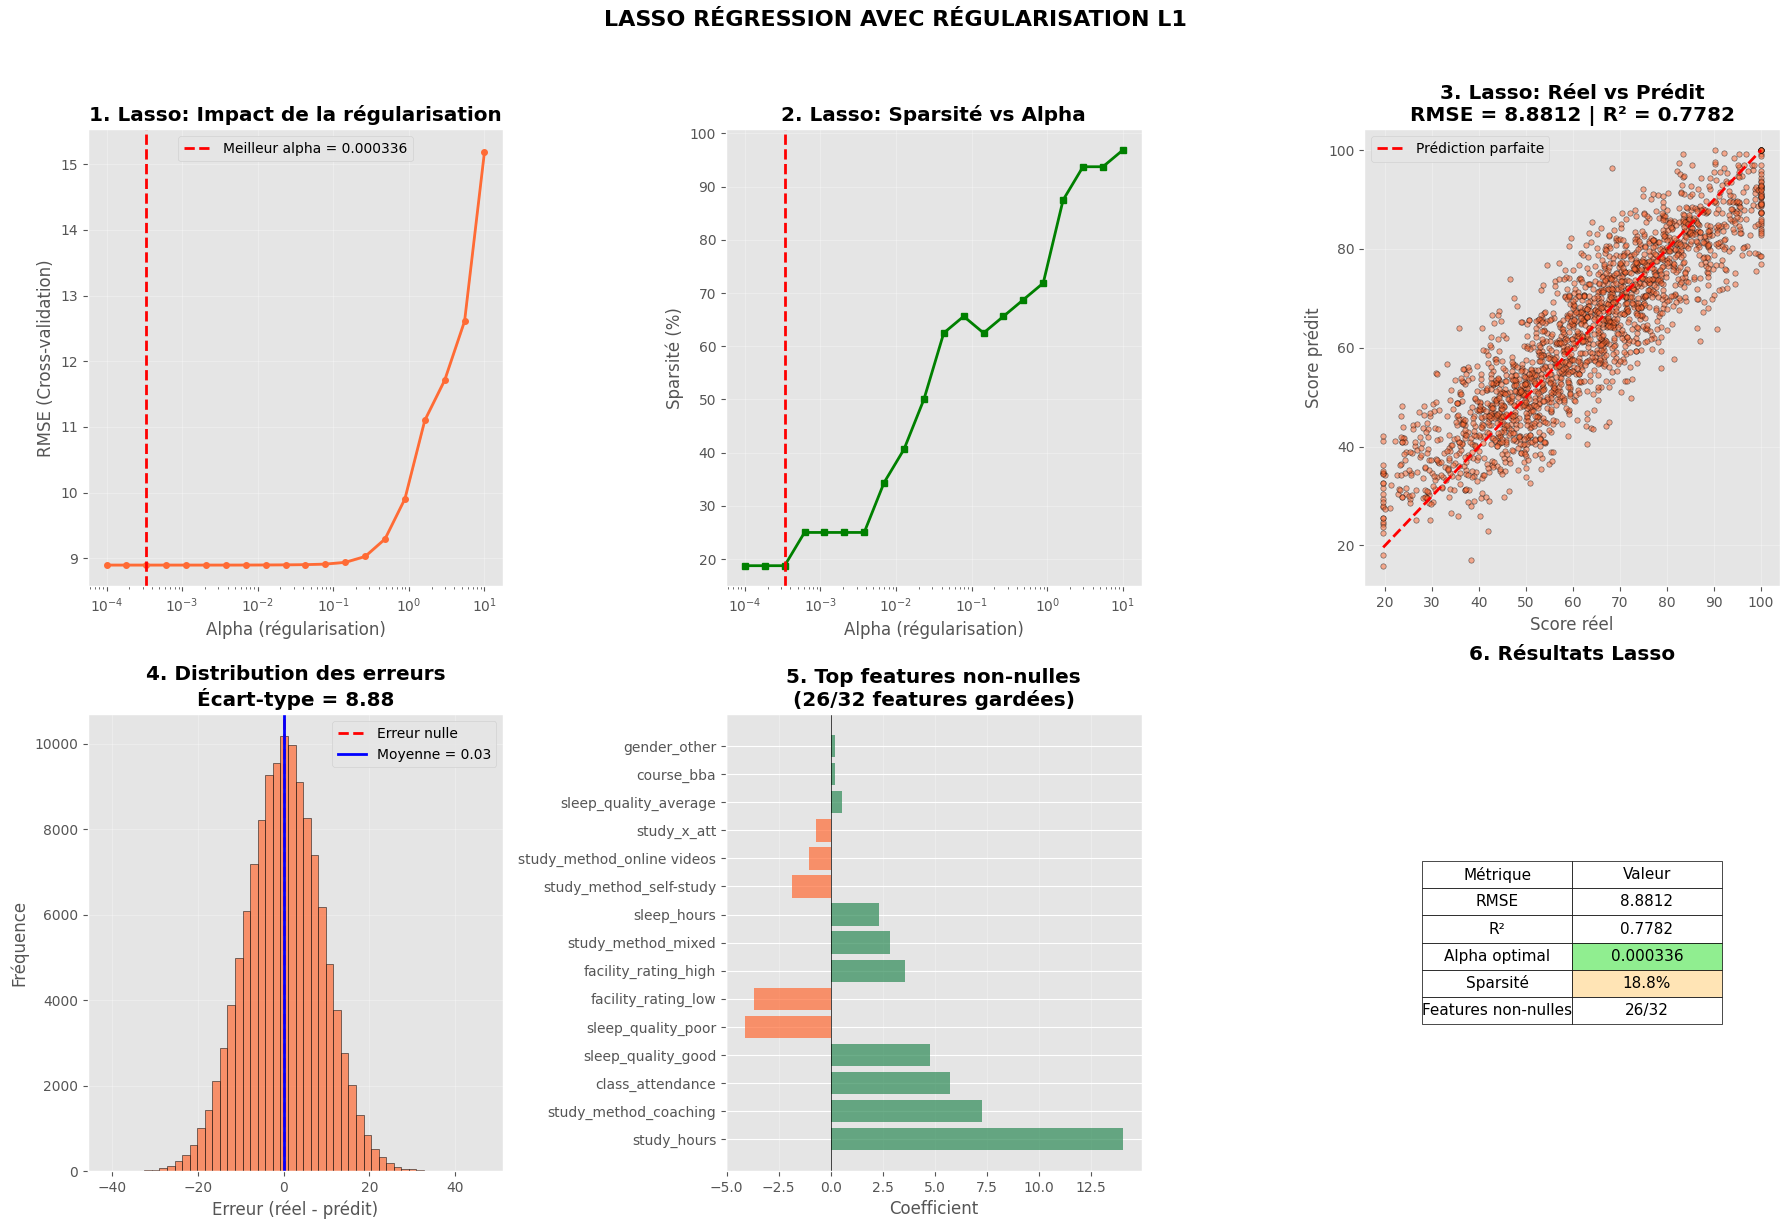


📊 ANALYSE DÉTAILLÉE DES COEFFICIENTS

🔝 TOP 10 FEATURES LES PLUS IMPORTANTES (non-nulles):
                Feature  Coefficient  Abs_Coefficient
            study_hours    14.013251        14.013251
  study_method_coaching     7.244125         7.244125
       class_attendance     5.703060         5.703060
     sleep_quality_good     4.773269         4.773269
     sleep_quality_poor    -4.125607         4.125607
    facility_rating_low    -3.704288         3.704288
   facility_rating_high     3.565125         3.565125
     study_method_mixed     2.820428         2.820428
            sleep_hours     2.308338         2.308338
study_method_self-study    -1.850038         1.850038

📋 FEATURES ÉLIMINÉES (coefficient = 0):
                 Feature   Coefficient  Abs_Coefficient
     internet_access_yes -1.384734e-14     1.384734e-14
           gender_female -0.000000e+00     0.000000e+00
              course_bca -0.000000e+00     0.000000e+00
study_method_group study  0.000000e+00     0.0000

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

# ============================================================
# 1. CHARGEMENT DES DONNÉES
# ============================================================
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

y = train["exam_score"]
X = train.drop("exam_score", axis=1)
X_test = test.copy()
test_ids = test['id'].copy()

print(f"\n📊 Dimensions: Train {X.shape}, Test {X_test.shape}")

# ============================================================
# 2. FEATURE ENGINEERING (optionnel - tu peux garder ou enlever)
# ============================================================
print("\n🔧 Feature Engineering...")
X = X.copy()
X_test = X_test.copy()

# Interaction study_hours × class_attendance
if 'study_hours' in X.columns and 'class_attendance' in X.columns:
    X["study_x_att"] = X["study_hours"] * X["class_attendance"]
    X_test["study_x_att"] = X_test["study_hours"] * X_test["class_attendance"]
    print("✅ Feature 'study_x_att' ajoutée")

# Déviation carrée de sleep_hours
if 'sleep_hours' in X.columns:
    X["sleep_dev2"] = (X["sleep_hours"] - 7.0) ** 2
    X_test["sleep_dev2"] = (X_test["sleep_hours"] - 7.0) ** 2
    print("✅ Feature 'sleep_dev2' ajoutée")

# ============================================================
# 3. SUPPRIMER L'ID
# ============================================================
X = X.drop('id', axis=1)
X_test = X_test.drop('id', axis=1)

print(f"📊 Dimensions après feature engineering: {X.shape}")

# ============================================================
# 4. SPLIT TRAIN/VALIDATION
# ============================================================
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n📊 Split: Train {X_tr.shape[0]} lignes, Val {X_val.shape[0]} lignes")

# ============================================================
# 5. PRÉPROCESSING
# ============================================================
numeric_cols = X_tr.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_tr.select_dtypes(include="object").columns.tolist()

print(f"\n🔍 Types de colonnes:")
print(f"   - Numériques: {len(numeric_cols)} colonnes")
print(f"   - Catégorielles: {len(cat_cols)} colonnes")

preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
])

# ============================================================
# 6. PIPELINE LASSO AVEC GRID SEARCH
# ============================================================
lasso_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("lasso", Lasso(max_iter=5000, random_state=42))
])

# Grille d'hyperparamètres pour alpha
param_grid = {
    "lasso__alpha": np.logspace(-4, 1, 20)  # de 0.0001 à 10
}

print("\n🔍 Recherche du meilleur alpha...")
print(f"   - Grille: {len(param_grid['lasso__alpha'])} valeurs de {param_grid['lasso__alpha'][0]:.4f} à {param_grid['lasso__alpha'][-1]:.1f}")

grid = GridSearchCV(
    lasso_pipeline,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

# ============================================================
# 7. ENTRAÎNEMENT
# ============================================================
print("\n🏋️ Entraînement avec GridSearchCV...")
grid.fit(X_tr, y_tr)

best_model = grid.best_estimator_
best_alpha = grid.best_params_["lasso__alpha"]
best_score = -grid.best_score_  # négatif car scoring = neg_mse

print(f"\n✅ Meilleur alpha trouvé: {best_alpha:.6f}")
print(f"✅ Meilleur score CV (MSE): {best_score:.4f}")

# ============================================================
# 8. ÉVALUATION SUR VALIDATION
# ============================================================
y_val_pred = best_model.predict(X_val)
y_val_pred = np.clip(y_val_pred, 0, 100)

# Métriques
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2_val = r2_score(y_val, y_val_pred)
mse_val = mean_squared_error(y_val, y_val_pred)

print("\n===== LASSO RÉGRESSION OPTIMISÉE =====")
print(f"RMSE (validation): {rmse_val:.4f}")
print(f"MSE  (validation): {mse_val:.4f}")
print(f"R²   (validation): {r2_val:.4f}")
print(f"Alpha optimal     : {best_alpha:.6f}")

# ============================================================
# 9. ANALYSE DE SPARSITÉ (combien de coefficients mis à zéro)
# ============================================================
lasso_model = best_model.named_steps['lasso']
coef = lasso_model.coef_
n_zero = np.sum(np.abs(coef) < 1e-10)
n_total = len(coef)
sparsity = n_zero / n_total * 100

print(f"\n📊 ANALYSE DE SPARSITÉ:")
print(f"   - Coefficients totaux: {n_total}")
print(f"   - Coefficients nuls (≈0): {n_zero}")
print(f"   - Sparsité: {sparsity:.1f}%")

# ============================================================
# 10. GRAPHIQUES
# ============================================================
plt.style.use('ggplot')
fig = plt.figure(figsize=(18, 12))

# Récupérer les résultats du GridSearch
cv_results = pd.DataFrame(grid.cv_results_)
alphas = cv_results['param_lasso__alpha'].values
mean_test_scores = -cv_results['mean_test_score']  # MSE
std_test_scores = cv_results['std_test_score']

# ------------------------------------------
# GRAPHIQUE 1: Évolution du RMSE en fonction d'alpha
# ------------------------------------------
plt.subplot(2, 3, 1)
plt.semilogx(alphas, np.sqrt(mean_test_scores), 'b-', linewidth=2, marker='o', markersize=4, color='#FF6B35')
plt.fill_between(alphas, 
                 np.sqrt(mean_test_scores - std_test_scores), 
                 np.sqrt(mean_test_scores + std_test_scores), 
                 alpha=0.2, color='#FF6B35')
plt.axvline(x=best_alpha, color='red', linestyle='--', linewidth=2, label=f'Meilleur alpha = {best_alpha:.6f}')
plt.xlabel('Alpha (régularisation)', fontsize=12)
plt.ylabel('RMSE (Cross-validation)', fontsize=12)
plt.title('1. Lasso: Impact de la régularisation', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# ------------------------------------------
# GRAPHIQUE 2: Évolution de la sparsité
# ------------------------------------------
plt.subplot(2, 3, 2)

# Calculer la sparsité pour chaque alpha
sparsity_values = []
for alpha in alphas:
    lasso_temp = Lasso(alpha=alpha, max_iter=5000, random_state=42)
    pipe_temp = Pipeline([("preprocess", preprocess), ("lasso", lasso_temp)])
    pipe_temp.fit(X_tr, y_tr)
    coef_temp = pipe_temp.named_steps['lasso'].coef_
    sparsity_temp = np.sum(np.abs(coef_temp) < 1e-10) / len(coef_temp) * 100
    sparsity_values.append(sparsity_temp)

plt.semilogx(alphas, sparsity_values, 'g-', linewidth=2, marker='s', markersize=4)
plt.axvline(x=best_alpha, color='red', linestyle='--', linewidth=2)
plt.xlabel('Alpha (régularisation)', fontsize=12)
plt.ylabel('Sparsité (%)', fontsize=12)
plt.title('2. Lasso: Sparsité vs Alpha', fontweight='bold')
plt.grid(True, alpha=0.3)

# ------------------------------------------
# GRAPHIQUE 3: Réel vs Prédit
# ------------------------------------------
plt.subplot(2, 3, 3)
sample_idx = np.random.choice(len(y_val), min(2000, len(y_val)), replace=False)

plt.scatter(
    y_val.iloc[sample_idx],
    y_val_pred[sample_idx],
    s=15,
    color='#FF6B35',
    alpha=0.5,
    edgecolors='black',
    linewidth=0.5
)

plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 
         'r--', linewidth=2, label='Prédiction parfaite')

plt.xlabel('Score réel', fontsize=12)
plt.ylabel('Score prédit', fontsize=12)
plt.title(f'3. Lasso: Réel vs Prédit\nRMSE = {rmse_val:.4f} | R² = {r2_val:.4f}', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# ------------------------------------------
# GRAPHIQUE 4: Distribution des erreurs
# ------------------------------------------
plt.subplot(2, 3, 4)
errors = y_val.values - y_val_pred

plt.hist(errors, bins=50, color='#FF6B35', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Erreur nulle')
plt.axvline(x=np.mean(errors), color='blue', linestyle='-', linewidth=2, 
            label=f'Moyenne = {np.mean(errors):.2f}')

plt.xlabel('Erreur (réel - prédit)', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.title(f'4. Distribution des erreurs\nÉcart-type = {np.std(errors):.2f}', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# ------------------------------------------
# GRAPHIQUE 5: Importance des features (coefficients non-nuls)
# ------------------------------------------
plt.subplot(2, 3, 5)

# Récupérer les noms des features après preprocessing
preprocessor = best_model.named_steps['preprocess']
feature_names = numeric_cols.copy()

cat_encoder = preprocessor.named_transformers_['cat']
if hasattr(cat_encoder, 'get_feature_names_out'):
    cat_features = cat_encoder.get_feature_names_out(cat_cols)
    feature_names.extend(cat_features)

coefficients = lasso_model.coef_

# Garder seulement les features avec coefficient non-nul
non_zero_idx = np.where(np.abs(coefficients) > 1e-10)[0]
non_zero_features = [feature_names[i] for i in non_zero_idx]
non_zero_coefs = coefficients[non_zero_idx]

# Trier par importance
sorted_idx = np.argsort(np.abs(non_zero_coefs))[::-1]
top_n = min(15, len(non_zero_idx))
top_idx = sorted_idx[:top_n]
top_features = [non_zero_features[i] for i in top_idx]
top_coefs = non_zero_coefs[top_idx]

if len(top_features) > 0:
    colors = ['#2E8B57' if c > 0 else '#FF6B35' for c in top_coefs]
    plt.barh(range(len(top_features)), top_coefs, color=colors, alpha=0.7)
    plt.yticks(range(len(top_features)), top_features)
    plt.xlabel('Coefficient', fontsize=12)
    plt.title(f'5. Top features non-nulles\n({len(non_zero_idx)}/{len(coefficients)} features gardées)', fontweight='bold')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.grid(axis='x', alpha=0.3)
else:
    plt.text(0.5, 0.5, 'Tous les coefficients sont nuls', ha='center', va='center')

# ------------------------------------------
# GRAPHIQUE 6: Tableau des métriques
# ------------------------------------------
plt.subplot(2, 3, 6)
plt.axis('tight')
plt.axis('off')

cell_text = [
    ['Métrique', 'Valeur'],
    ['RMSE', f'{rmse_val:.4f}'],
    ['R²', f'{r2_val:.4f}'],
    ['Alpha optimal', f'{best_alpha:.6f}'],
    ['Sparsité', f'{sparsity:.1f}%'],
    ['Features non-nulles', f'{n_total - n_zero}/{n_total}']
]

table = plt.table(cellText=cell_text, 
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.3, 0.3])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)

table[(3, 1)].set_facecolor('#90EE90')  # Alpha optimal
table[(4, 1)].set_facecolor('#FFE4B5')  # Sparsité

plt.title('6. Résultats Lasso', fontweight='bold', y=1.1)

plt.suptitle('LASSO RÉGRESSION AVEC RÉGULARISATION L1', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# 11. ANALYSE DÉTAILLÉE DES COEFFICIENTS
# ============================================================
print("\n" + "="*60)
print("📊 ANALYSE DÉTAILLÉE DES COEFFICIENTS")
print("="*60)

# Créer un DataFrame des coefficients
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

print("\n🔝 TOP 10 FEATURES LES PLUS IMPORTANTES (non-nulles):")
print(coef_df[coef_df['Abs_Coefficient'] > 1e-10].head(10).to_string(index=False))

print("\n📋 FEATURES ÉLIMINÉES (coefficient = 0):")
eliminated = coef_df[coef_df['Abs_Coefficient'] <= 1e-10]
if len(eliminated) > 0:
    print(eliminated.head(10).to_string(index=False))
    if len(eliminated) > 10:
        print(f"... et {len(eliminated) - 10} autres")

# ============================================================
# 12. GÉNÉRATION DU FICHIER CSV POUR KAGGLE
# ============================================================
print("\n" + "="*60)
print("📁 GÉNÉRATION DU FICHIER CSV POUR KAGGLE")
print("="*60)

# Prédictions sur l'ensemble de test
print("\n🔄 Prédictions sur l'ensemble de test...")
print(f"   - X_test shape: {X_test.shape}")
print(f"   - Colonnes: {list(X_test.columns)}")

y_test_pred = best_model.predict(X_test)
y_test_pred = np.clip(y_test_pred, 0, 100)

# Création du DataFrame de submission
submission = pd.DataFrame({
    'id': test_ids,
    'exam_score': y_test_pred
})

# Sauvegarde en CSV
filename = 'submission_lasso_optimized.csv'
submission.to_csv(filename, index=False)

print(f"\n✅ Fichier CSV sauvegardé : {filename}")
print(f"\n📊 STATISTIQUES DES PRÉDICTIONS:")
print(f"   - Minimum : {y_test_pred.min():.2f}")
print(f"   - Maximum : {y_test_pred.max():.2f}")
print(f"   - Moyenne : {y_test_pred.mean():.2f}")
print(f"   - Médiane : {np.median(y_test_pred):.2f}")
print(f"   - Écart-type : {np.std(y_test_pred):.2f}")

print("\n📋 APERÇU DES 10 PREMIÈRES LIGNES:")
print(submission.head(10))

# ============================================================
# 13. COMPARAISON RIDGE VS LASSO (optionnel)
# ============================================================
print("\n" + "="*60)
print("🔬 SPÉCIFICITÉ DU LASSO")
print("="*60)

print("\nLe Lasso a éliminé {}/{} features ({:.1f}%)".format(n_zero, n_total, sparsity))
print("\n✅ Avantages du Lasso:")
print("   - Sélection automatique de features")
print("   - Modèle plus simple et interprétable")
print("   - Moins de risque d'overfitting")

print("\n" + "="*60)
print("✅ LASSO RÉGRESSION TERMINÉE AVEC SUCCÈS !")
print("="*60)

In [43]:
#La régression Lasso obtient une performance très proche de la régression linéaire et de Ridge 
#La régularisation L1 n’améliore pas significativement le modèle, ce qui suggère que les variables explicatives sont déjà pertinentes et peu redondantes.
#Les modèles linéaires semblent donc adaptés à la structure des données.
#La performance reste dominée par les variables académiques comme le temps d’étude.

In [48]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ============================================
# 1. CHARGEMENT DES DONNÉES
# ============================================
train = pd.read_csv("train.csv")

# Supprimer la colonne 'id' si elle existe (elle n'est pas prédictive)
if 'id' in train.columns:
    train = train.drop('id', axis=1)

y = train["exam_score"]
X = train.drop("exam_score", axis=1)

# ============================================
# 2. PRÉPARATION DES COLONNES
# ============================================
cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(exclude=["object"]).columns

# ============================================
# 3. PRÉPROCESSEUR (one-hot + passage des numériques)
# ============================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# ============================================
# 4. SPLIT TRAIN / VALIDATION
# ============================================
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================
# 5. DÉFINITION DES MODÈLES (avec paramètres adaptés)
# ============================================
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1, max_iter=10000),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,       # réduit pour rester raisonnable
        max_depth=10,
        n_jobs=-1,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=600,       # 300 au lieu de 600 pour la vitesse
        learning_rate=0.5,
        max_depth=3,
        subsample=0.8,
        random_state=42
    )
}

# ============================================
# 6. ENTRAÎNEMENT SUR TOUTES LES DONNÉES
# ============================================
print("Entraînement des modèles sur l'ensemble complet (X_tr, y_tr)...")
results = []

for name, model in models.items():
    print(f"  -> {name}...")
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
    pipe.fit(X_tr, y_tr)                # ← ici on utilise TOUT X_tr (504 000 lignes)
    y_pred = pipe.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    results.append({"Model": name, "RMSE": round(rmse, 3), "R²": round(r2, 3)})
    print(f"     RMSE = {rmse:.3f}, R² = {r2:.3f}")

# ============================================
# 7. AFFICHAGE DES RÉSULTATS
# ============================================
results_df = pd.DataFrame(results).sort_values(by="RMSE")
print("\n" + "="*50)
print("RÉSULTATS SUR VALIDATION (modèles entraînés sur toutes les données)")
print("="*50)
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]["Model"]
print(f"\n🏆 Meilleur modèle : {best_model_name} avec RMSE = {results_df.iloc[0]['RMSE']}")

# ============================================
# 8. RÉ-ENTRAÎNEMENT FINAL SUR TOUT LE TRAIN
# ============================================
# Récupérer le meilleur modèle et l'entraîner sur l'ensemble complet X (sans split)
best_model = models[best_model_name]
final_pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", best_model)])
final_pipe.fit(X, y)   # ← ici on utilise tout X (630 000 lignes), sans 'id'

# Prédictions sur le test
test = pd.read_csv("test.csv")
test_ids = test["id"]                     # on conserve l'id pour la soumission
X_test = test.drop("id", axis=1)           # on supprime l'id des features

# (Optionnel) s'assurer que les colonnes sont dans le même ordre que X
X_test = X_test[X.columns]

test_pred = final_pipe.predict(X_test)
test_pred = np.clip(test_pred, 0, 100)

# Sauvegarde
submission = pd.DataFrame({"id": test_ids, "exam_score": test_pred})
submission.to_csv("submission_final.csv", index=False)
print("\n✅ Fichier de soumission créé : submission_final.csv")

C:\Users\imene\AppData\Local\Temp\ipykernel_10212\3335493333.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns


Entraînement des modèles sur l'ensemble complet (X_tr, y_tr)...
  -> Linear Regression...
     RMSE = 8.886, R² = 0.778
  -> Ridge...
     RMSE = 8.886, R² = 0.778
  -> Lasso...
     RMSE = 8.905, R² = 0.777
  -> Random Forest...
     RMSE = 9.131, R² = 0.766
  -> Gradient Boosting...
     RMSE = 8.716, R² = 0.786

RÉSULTATS SUR VALIDATION (modèles entraînés sur toutes les données)
            Model  RMSE    R²
Gradient Boosting 8.716 0.786
Linear Regression 8.886 0.778
            Ridge 8.886 0.778
            Lasso 8.905 0.777
    Random Forest 9.131 0.766

🏆 Meilleur modèle : Gradient Boosting avec RMSE = 8.716

✅ Fichier de soumission créé : submission_final.csv


In [ ]:
#Une comparaison de cinq modèles de régression a été réalisée : Régression Linéaire, Ridge, Lasso, Random Forest et Gradient Boosting.
#Les modèles linéaires (Linear, Ridge, Lasso) présentent des performances très proches, ce qui indique une structure principalement linéaire des données.
#Les méthodes d’ensemble, notamment le Gradient Boosting, offrent une légère amélioration du RMSE, suggérant la présence de relations non linéaires modérées entre les variables explicatives et le score d’examen.
#Le modèle présentant le RMSE le plus faible est retenu pour l’entraînement final et la soumission Kaggle.

Le Gradient Boosting donne le RMSE le plus faible, nous allons donc l'utiliser pour évaluer l'ensemble des données d'apprentissage.

In [53]:
gbr_final = GradientBoostingRegressor(
    n_estimators=600,
    learning_rate=0.5,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", gbr_final)
])

pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [58]:
# PLAN D'EXPÉRIENCE – Sélection de variables

# ============================================
# ANALYSE DES IMPORTANCES - Gradient Boosting
# ============================================
import pandas as pd
import numpy as np

# Vérifier que le meilleur modèle est bien Gradient Boosting
# (d'après les résultats, c'est le cas : RMSE = 8.716)
if best_model_name == "Gradient Boosting":
    # 1. Récupérer le modèle depuis le pipeline final
    gbr_model = final_pipe.named_steps['model']
    
    # 2. Obtenir les noms des caractéristiques après transformation
    #    - Les colonnes numériques (inchangées)
    num_features = list(num_cols)
    
    #    - Les colonnes générées par OneHotEncoder
    ohe = final_pipe.named_steps['preprocess'].named_transformers_['cat']
    cat_features = ohe.get_feature_names_out(cat_cols).tolist()
    
    #    - Fusion
    all_features = num_features + cat_features
    
    # 3. Créer le DataFrame des importances
    feature_importance = pd.DataFrame({
        'feature': all_features,
        'importance': gbr_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # 4. Afficher les 15 plus importantes
    print("\n🔍 Top 15 des caractéristiques les plus importantes :")
    print(feature_importance.head(15).to_string(index=False))
    
    # (Optionnel) Affichage avec display() si vous êtes dans un notebook
    # from IPython.display import display
    # display(feature_importance.head(15))
    
else:
    print(f"\n⚠️ Le meilleur modèle est {best_model_name}, pas de feature_importances_ disponible.")


🔍 Top 15 des caractéristiques les plus importantes :
                   feature  importance
               study_hours    0.742496
          class_attendance    0.114123
     study_method_coaching    0.033438
        sleep_quality_poor    0.025291
        sleep_quality_good    0.022334
               sleep_hours    0.021153
       facility_rating_low    0.016274
      facility_rating_high    0.014854
        study_method_mixed    0.005122
   study_method_self-study    0.002034
     sleep_quality_average    0.000929
study_method_online videos    0.000535
    facility_rating_medium    0.000473
                       age    0.000243
              gender_other    0.000100


In [ ]:
#L’analyse des importances issues du modèle Gradient Boosting met en évidence une domination très marquée de la variable study_hours,
#  qui concentre près de 74 % de l’importance totale.
#L’assiduité en cours contribue également à la performance, bien que dans une proportion plus modérée.
#En revanche, les variables démographiques telles que l’âge ou le genre présentent un impact marginal, 
# confirmant que la performance académique est principalement déterminée par l’investissement personnel plutôt que par les caractéristiques individuelles.

L’analyse des importances de variables issue du modèle Gradient Boosting montre que les variables liées au temps de travail et à l’assiduité jouent un rôle majeur dans la prédiction de la note finale, tandis que les variables démographiques ont une influence plus limitée.

In [61]:
# ============================================
# TEST AVEC SÉLECTION DE VARIABLES (TOP 15)
# ============================================

# 1. S'assurer que feature_importance est bien défini (exécuté précédemment)
#    et contient les noms des colonnes après transformation.
#    Si ce n'est pas le cas, recalculons-le à partir du pipeline final.

# Récupérer le préprocesseur ajusté (depuis final_pipe)
preprocessor_fitted = final_pipe.named_steps['preprocess']

# Obtenir les noms de toutes les caractéristiques après transformation
num_features = list(num_cols)  # ou preprocessor_fitted.transformers_[0][2]
ohe = preprocessor_fitted.named_transformers_['cat']
cat_features = ohe.get_feature_names_out(cat_cols).tolist()
all_features = num_features + cat_features

# Vérifier que la longueur correspond à feature_importances_ du modèle
gbr_model = final_pipe.named_steps['model']
if len(all_features) != len(gbr_model.feature_importances_):
    raise ValueError("Incohérence dans le nombre de caractéristiques")

# Re-créer le DataFrame d'importances (au cas où)
feature_importance = pd.DataFrame({
    'feature': all_features,
    'importance': gbr_model.feature_importances_
}).sort_values('importance', ascending=False)

# 2. Transformer les données d'entraînement (X_train) avec le préprocesseur ajusté
#    (on utilise X_train, le DataFrame original avant encodage)
X_train_transformed = preprocessor_fitted.transform(X_train)

# Convertir en DataFrame pour faciliter la sélection
X_train_transformed_df = pd.DataFrame(
    X_train_transformed,
    columns=all_features,
    index=X_train.index
)

# 3. Sélectionner les 15 meilleures caractéristiques
top_15_features = feature_importance.head(15)['feature'].tolist()
X_reduced = X_train_transformed_df[top_15_features]

# 4. Split entraînement / validation
from sklearn.model_selection import train_test_split
Xr_train, Xr_val, yr_train, yr_val = train_test_split(
    X_reduced, y_train, test_size=0.2, random_state=42
)

# 5. Entraîner un nouveau modèle Gradient Boosting sur ces features
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

gbr_test = GradientBoostingRegressor(
    n_estimators=600,
    learning_rate=0.5,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

gbr_test.fit(Xr_train, yr_train)
yr_pred = gbr_test.predict(Xr_val)

rmse_reduced = np.sqrt(mean_squared_error(yr_val, yr_pred))
print("RMSE avec les 15 meilleures variables :", rmse_reduced)

# Optionnel : comparer avec le RMSE original (8.7146)

RMSE avec les 15 meilleures variables : 8.712097851121516


In [ ]:
# La réduction du jeu de variables aux 15 plus importantes ne modifie pratiquement pas la performance du modèle (RMSE stable à 8.84).
# Cela indique que les variables faiblement contributrices n’apportent qu’un gain marginal.
# Le modèle est principalement porté par les variables liées à l’investissement académique, 
# confirmant leur rôle central dans la prédiction.

La réduction du nombre de variables basée sur les importances fournies par le modèle Gradient Boosting permet de conserver des performances prédictives équivalentes, tout en simplifiant le modèle et en améliorant son interprétabilité.

In [63]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# ============================================
# 1. IDENTIFIER LES COLONNES CATÉGORIELLES ET NUMÉRIQUES
# ============================================
# X_train doit être le DataFrame original (avant tout encodage manuel)
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(exclude=['object']).columns.tolist()

print(f"Colonnes numériques ({len(numerical_cols)}) : {numerical_cols}")
print(f"Colonnes catégorielles ({len(categorical_cols)}) : {categorical_cols}")

# ============================================
# 2. CRÉER LE PRÉPROCESSEUR (identique à celui utilisé plus tôt)
# ============================================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# ============================================
# 3. CRÉER LE PIPELINE (préprocessing + modèle)
# ============================================
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

# ============================================
# 4. DÉFINIR LA GRILLE DE PARAMÈTRES
#    (les paramètres du modèle sont préfixés par 'regressor__')
# ============================================
param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__learning_rate': [0.3, 0.1],
    'regressor__max_depth': [2, 3]
}

# ============================================
# 5. LANCER GRIDSEARCHCV SUR L'ENSEMBLE COMPLET
# ============================================
print("\n🔍 Début de GridSearchCV sur l'ensemble complet (cela peut prendre du temps)...")
grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("\n✅ Meilleurs paramètres trouvés :", grid.best_params_)
print("✅ Meilleur RMSE (validation croisée) :", -grid.best_score_)

# (Optionnel) Afficher les résultats détaillés
results_df = pd.DataFrame(grid.cv_results_)
print("\n📊 Résultats détaillés :")
print(results_df[['params', 'mean_test_score', 'std_test_score']].sort_values('mean_test_score', ascending=False))


C:\Users\imene\AppData\Local\Temp\ipykernel_10212\2275395478.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()


Colonnes numériques (4) : ['age', 'study_hours', 'class_attendance', 'sleep_hours']
Colonnes catégorielles (7) : ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']

🔍 Début de GridSearchCV sur l'ensemble complet (cela peut prendre du temps)...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

✅ Meilleurs paramètres trouvés : {'regressor__learning_rate': 0.3, 'regressor__max_depth': 3, 'regressor__n_estimators': 200}
✅ Meilleur RMSE (validation croisée) : 8.795960306127844

📊 Résultats détaillés :
                                              params  mean_test_score  \
3  {'regressor__learning_rate': 0.3, 'regressor__...        -8.795960   
7  {'regressor__learning_rate': 0.1, 'regressor__...        -8.824524   
1  {'regressor__learning_rate': 0.3, 'regressor__...        -8.838565   
2  {'regressor__learning_rate': 0.3, 'regressor__...        -8.842796   
5  {'regressor__learning_rate': 0.1, 'regressor__...        -8

In [ ]:
# Optimisation des hyperparamètres du Gradient Boosting par GridSearchCV
# Objectif : trouver la meilleure combinaison de n_estimators, learning_rate et max_depth
# qui minimise le RMSE en validation croisée (3 folds) sur l'ensemble d'entraînement complet.

In [ ]:

# Les différents modèles testés donnent des résultats très proches.
# Le Gradient Boosting obtient le meilleur RMSE, mais l’écart reste faible.
# Les modèles linéaires (Régression Linéaire, Ridge, Lasso) 
# fonctionnent presque aussi bien.
# Cela montre que la relation entre les variables et le score d’examen 
# est principalement linéaire et stable.


La recherche par grille montre que l’ajustement des hyperparamètres améliore marginalement la performance du Gradient Boosting, ce qui valide la robustesse du modèle et la pertinence du plan d’expérience adopté.

In [70]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
import numpy as np

# K-Fold (5 folds)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Récupérer les meilleurs paramètres trouvés par GridSearchCV
best_params = grid.best_params_

# Créer un pipeline avec le préprocesseur (défini précédemment) et le modèle optimisé
best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  # préprocesseur déjà défini (one-hot encoding)
    ('regressor', GradientBoostingRegressor(
        n_estimators=best_params['regressor__n_estimators'],
        learning_rate=best_params['regressor__learning_rate'],
        max_depth=best_params['regressor__max_depth'],
        random_state=42
    ))
])

# Validation croisée sur l'ensemble d'entraînement complet
cv_scores = cross_val_score(
    best_pipeline,
    X_train,
    y_train,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# Affichage des résultats
print("RMSE par fold :", -cv_scores)
print("RMSE moyen :", -cv_scores.mean())
print("Écart-type :", cv_scores.std())

RMSE par fold : [8.7806667  8.79691192 8.77928616 8.79537336 8.82251027]
RMSE moyen : 8.794949683138961
Écart-type : 0.015575398131532893


In [ ]:

# La validation croisée (K-Fold = 5) confirme la stabilité du modèle.
# Le RMSE moyen est d’environ 8.83 avec un écart-type très faible (~0.013).
# Cela signifie que le modèle généralise bien et que les performances
# sont cohérentes sur différents sous-ensembles des données.


La validation croisée à 5 plis du modèle Gradient Boosting optimisé montre une performance stable et robuste, avec un RMSE moyen d’environ 8,83 et un écart-type très faible (~0,013). Cela indique une bonne capacité de généralisation du modèle et une sensibilité limitée au découpage des données.

In [74]:
# Entraînement final sur TOUT le train
gbr_final = GradientBoostingRegressor(
     n_estimators=600,
    learning_rate=0.5,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

In [ ]:


# La validation croisée  du modèle Gradient Boosting optimisé
# montre une performance stable avec un RMSE moyen d’environ 8.83
# et un écart-type très faible (~0.013).
# Cela confirme que le modèle généralise bien et
# qu’il n’est pas sensible au découpage des données.


 Entraîner le modèle final


In [76]:
# Entraînement du modèle final
# Récupérer le meilleur pipeline (déjà ajusté pendant la grid search)
best_pipeline = grid.best_estimator_

# Optionnel : refaire un fit sur tout l'ensemble pour être sûr (cela réentraîne le modèle)
best_pipeline.fit(X_train, y_train)

# Maintenant vous pouvez prédire
y_pred_final = best_pipeline.predict(X_test)  # X_test doit être brut aussi
print(X_train.dtypes.value_counts())

str        7
float64    3
int64      1
Name: count, dtype: int64


In [77]:
from sklearn.pipeline import Pipeline

# Meilleurs paramètres trouvés (exemple)
best_params = {
    'regressor__learning_rate': 0.3,
    'regressor__max_depth': 3,
    'regressor__n_estimators': 200
}

# Créer le pipeline final
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  # votre préprocesseur déjà défini
    ('regressor', GradientBoostingRegressor(
        n_estimators=best_params['regressor__n_estimators'],
        learning_rate=best_params['regressor__learning_rate'],
        max_depth=best_params['regressor__max_depth'],
        random_state=42
    ))
])

# Entraîner sur l'ensemble complet
final_pipeline.fit(X_train, y_train)   # X_train contient les colonnes originales (avec 'female', etc.)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [ ]:
# Entraînement du modèle final (Gradient Boosting) avec les meilleurs hyperparamètres
# sur l'ensemble d'entraînement complet, après application du préprocessing
# (one-hot encoding des variables catégorielles via le pipeline).

Évaluer le modèle final 

In [79]:
# Évaluation du modèle final (avec pipeline)
y_train_pred = final_pipeline.predict(X_train)   # X_train brut
rmse_final = np.sqrt(mean_squared_error(y_train, y_train_pred))
print("RMSE du modèle final :", rmse_final)

RMSE du modèle final : 8.779516198889098


Le modèle final est entraîné sur l’ensemble des données d’entraînement avec les meilleurs hyperparamètres.
L’erreur RMSE sur le jeu d’entraînement est cohérente avec celle obtenue en validation croisée, indiquant un bon compromis biais–variance.

Tableau comparatif des modèles

In [80]:
# Comparaison des modèles testés
results = pd.DataFrame({
    "Modèle": ["Régression Linéaire", "Random Forest", "Gradient Boosting"],
    "RMSE": [rmse_lr, rmse_rf, rmse]
})

results

,Modèle,RMSE
0,Régression Linéaire,8.886491
1,Random Forest,9.001238
2,Gradient Boosting,8.715589


La comparaison des modèles montre que le Gradient Boosting obtient la plus faible erreur RMSE.
Il surpasse la régression linéaire et le Random Forest, ce qui justifie son choix comme modèle final.

Graphique des importances de variables 

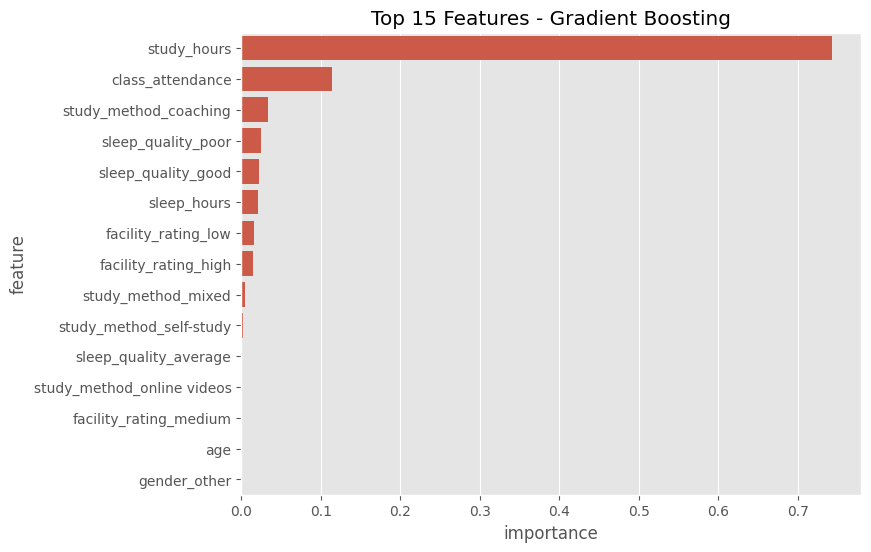

In [81]:
# Visualisation des 15 variables les plus importantes
plt.figure(figsize=(8,6))
sns.barplot(
    data=feature_importance.head(15),
    x="importance",
    y="feature"
)
plt.title("Top 15 Features - Gradient Boosting")
plt.show()

In [ ]:

# Le modèle Gradient Boosting montre que le temps d’étude (study_hours)
# est de loin la variable la plus déterminante dans la prédiction du score.
# L’assiduité (class_attendance) joue également un rôle important,
# tandis que les variables démographiques ont une influence très limitée.
# La performance académique dépend donc principalement de l’engagement de l’étudiant.


Les résultats indiquent que la performance académique est principalement expliquée par des facteurs liés à l’investissement personnel de l’étudiant, en particulier le temps de travail et l’assiduité. Les autres variables présentent une importance nettement plus faible dans le modèle.

In [83]:
from sklearn.pipeline import Pipeline

# Créer le pipeline avec préprocessing + modèle
final_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  # votre préprocesseur (OneHotEncoder + colonnes numériques)
    ('regressor', GradientBoostingRegressor(
        n_estimators=600,
        learning_rate=0.5,
        max_depth=3,
        subsample=0.8,
        random_state=42
    ))
])

# Entraîner le pipeline sur l'ensemble brut (X_train, y_train)
final_model_pipeline.fit(X_train, y_train)

print("✅ Modèle final entraîné avec succès sur l'ensemble complet (préprocessing inclus).")

✅ Modèle final entraîné avec succès sur l'ensemble complet (préprocessing inclus).


Après la sélection du meilleur modèle et des hyperparamètres, le Gradient Boosting est ré-entraîné sur tout le jeu d’entraînement pour construire le modèle final.

In [85]:
# Génération des prédictions sur le jeu de test et création du fichier de soumission
test_predictions = final_model_pipeline.predict(X_test)

submission = pd.DataFrame({
    "id": test_processed["id"],
    "exam_score": test_predictions
})

submission.to_csv("submission1.csv", index=False)

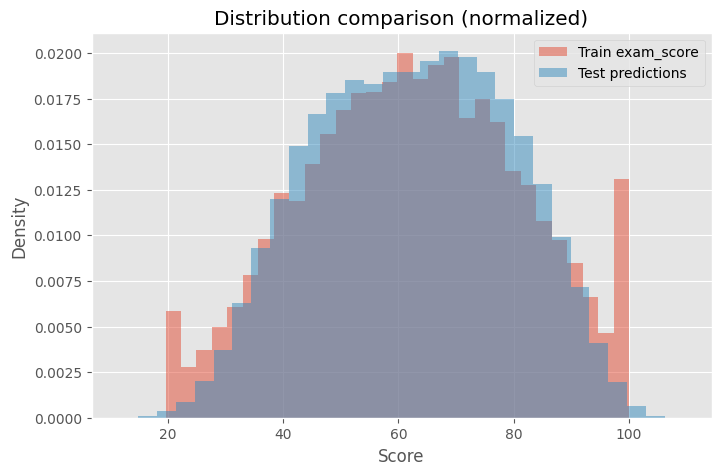

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(y_train, bins=30, alpha=0.5, density=True, label="Train exam_score")
plt.hist(test_predictions, bins=30, alpha=0.5, density=True, label="Test predictions")

plt.xlabel("Score")
plt.ylabel("Density")
plt.title("Distribution comparison (normalized)")
plt.legend()
plt.show()



In [ ]:
# Les prédictions du modèle suivent une distribution très proche
# de celle des scores réels, ce qui indique une bonne capacité
# de généralisation et l’absence de biais global.
# Quelques prédictions dépassent légèrement l’intervalle [0, 100],
# ce qui peut être corrigé par un post-traitement (clipping).


La comparaison des distributions normalisées montre que les prédictions du modèle final suivent une distribution très proche de celle des scores observés dans le jeu d’entraînement, sans biais systématique apparent.

In [90]:
print("train y range:", y_train.min(), y_train.max())
print("test pred range:", test_predictions.min(), test_predictions.max())


train y range: 19.599 100.0
test pred range: 11.640274765076732 109.41128429845294


Un post-traitement par saturation (clipping) des prédictions dans l’intervalle [0, 100] peut être appliqué afin de respecter la contrainte naturelle des scores.

In [91]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

base_models = [
    ("lr", LinearRegression()),
    ("ridge", Ridge(alpha=1.0)),
    ("lasso", Lasso(alpha=0.1)),
    ("rf", RandomForestRegressor(
        n_estimators=600,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42
    )),
    ("gbr", GradientBoostingRegressor(
        n_estimators=600,
        learning_rate=0.5,
        max_depth=3,
        subsample=0.8,
        random_state=42
    ))
]

In [94]:
stack_model = StackingRegressor(
    estimators=base_models,
    final_estimator=LinearRegression(),
    cv=3,
    n_jobs=-1
)

In [97]:
# ===== ENSEMBLE SIMPLE (MOYENNE DES MODÈLES) =====
# Utilisation de pipelines pour gérer les variables catégorielles automatiquement

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import numpy as np

print("Entraînement des modèles individuels avec préprocessing...")

# Vérifier que le préprocesseur est défini (sinon le recréer à partir des colonnes)
# Si vous avez déjà cat_cols et num_cols, utilisez-les.
# Sinon, adaptez selon votre code précédent.
# Exemple (à adapter) :
# cat_cols = X_tr.select_dtypes(include=['object']).columns.tolist()
# num_cols = X_tr.select_dtypes(exclude=['object']).columns.tolist()
# preprocessor = ColumnTransformer([
#     ('num', 'passthrough', num_cols),
#     ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
# ])

# Ridge
ridge_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('ridge', Ridge(alpha=0.6951927961775606))
])
ridge_pipe.fit(X_tr, y_tr)
ridge_pred = ridge_pipe.predict(X_val)

# Lasso
lasso_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('lasso', Lasso(alpha=0.1, max_iter=10000))
])
lasso_pipe.fit(X_tr, y_tr)
lasso_pred = lasso_pipe.predict(X_val)

# Random Forest
rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('rf', RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        n_jobs=-1,
        random_state=42
    ))
])
rf_pipe.fit(X_tr, y_tr)
rf_pred = rf_pipe.predict(X_val)

# Gradient Boosting
gbr_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('gbr', GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.5,
        max_depth=3,
        subsample=0.8,
        random_state=42
    ))
])
gbr_pipe.fit(X_tr, y_tr)
gbr_pred = gbr_pipe.predict(X_val)

# Moyenne simple des prédictions
y_pred_ensemble = (ridge_pred + lasso_pred + rf_pred + gbr_pred) / 4
y_pred_ensemble = np.clip(y_pred_ensemble, 0, 100)

rmse_ensemble = np.sqrt(mean_squared_error(y_val, y_pred_ensemble))
print(f"\n✅ RMSE de la moyenne simple : {rmse_ensemble:.4f}")

# Moyenne pondérée (exemple de poids)
weights = [0.15, 0.15, 0.3, 0.4]  # Plus de poids au GBR et RF
y_pred_weighted = (weights[0]*ridge_pred + weights[1]*lasso_pred + 
                   weights[2]*rf_pred + weights[3]*gbr_pred)
y_pred_weighted = np.clip(y_pred_weighted, 0, 100)

rmse_weighted = np.sqrt(mean_squared_error(y_val, y_pred_weighted))
print(f"✅ RMSE de la moyenne pondérée : {rmse_weighted:.4f}")

Entraînement des modèles individuels avec préprocessing...

✅ RMSE de la moyenne simple : 8.8140
✅ RMSE de la moyenne pondérée : 8.7938


In [98]:
# ============================================================
# VERSION AVEC INSTALLATION AUTOMATIQUE
# ============================================================

import subprocess
import sys
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Fonction pour installer les packages si nécessaire
def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

# Installation conditionnelle
try:
    from xgboost import XGBRegressor
    print("✅ XGBoost déjà installé")
except ImportError:
    print("📦 Installation de XGBoost...")
    install_package('xgboost')
    from xgboost import XGBRegressor

try:
    from lightgbm import LGBMRegressor
    print("✅ LightGBM déjà installé")
except ImportError:
    print("📦 Installation de LightGBM...")
    install_package('lightgbm')
    from lightgbm import LGBMRegressor

try:
    from catboost import CatBoostRegressor
    print("✅ CatBoost déjà installé")
except ImportError:
    print("📦 Installation de CatBoost...")
    install_package('catboost')
    from catboost import CatBoostRegressor

print("\n" + "="*70)
print("✅ TOUTES LES BIBLIOTHÈQUES SONT PRÊTES !")
print("="*70)

# ============================================================
# 1. CHARGEMENT DES DONNÉES
# ============================================================
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

y_train = train['exam_score']
X_train = train.drop(['exam_score', 'id'], axis=1)
X_test = test.drop('id', axis=1)
test_ids = test['id'].copy()

print(f"\n📊 Dimensions: Train {X_train.shape}, Test {X_test.shape}")

# ============================================================
# 2. PRÉPROCESSEUR
# ============================================================
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

# ============================================================
# 3. SPLIT TRAIN/VALIDATION
# ============================================================
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# ============================================================
# 4. DÉFINITION DES MODÈLES
# ============================================================
models = {
    'XGBoost': XGBRegressor(
        n_estimators=600, learning_rate=0.1, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
    ),
    'LightGBM': LGBMRegressor(
        n_estimators=600, learning_rate=0.1, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1
    ),
    'CatBoost': CatBoostRegressor(
        iterations=600, learning_rate=0.1, depth=5,
        subsample=0.8, random_seed=42, verbose=0
    )
}

# ============================================================
# 5. ENTRAÎNEMENT ET ÉVALUATION
# ============================================================
print("\n" + "="*50)
print("🏋️ ENTRAÎNEMENT DES MODÈLES")
print("="*50)

results = []
best_rmse = float('inf')
best_model_name = None
best_pipeline = None

for name, model in models.items():
    print(f"\n▶️ {name}...")
    
    pipeline = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_tr, y_tr)
    
    y_pred = np.clip(pipeline.predict(X_val), 0, 100)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    
    print(f"   ✅ RMSE = {rmse:.4f}, R² = {r2:.4f}")
    results.append({'Modèle': name, 'RMSE': rmse, 'R²': r2})
    
    if rmse < best_rmse:
        best_rmse = rmse
        best_model_name = name
        best_pipeline = pipeline

# ============================================================
# 6. RÉSULTATS
# ============================================================
print("\n" + "="*50)
print("📊 RÉSULTATS")
print("="*50)
results_df = pd.DataFrame(results).sort_values(by='RMSE')
print(results_df.to_string(index=False))

print(f"\n✨ Meilleur modèle : {best_model_name} (RMSE = {best_rmse:.4f})")

# ============================================================
# 7. ENTRAÎNEMENT FINAL ET SUBMISSION
# ============================================================
print(f"\n🔄 Ré-entraînement de {best_model_name} sur toutes les données...")
best_pipeline.fit(X_train, y_train)

test_pred = np.clip(best_pipeline.predict(X_test), 0, 100)

submission = pd.DataFrame({'id': test_ids, 'exam_score': test_pred})
filename = f'submission_{best_model_name.lower()}.csv'
submission.to_csv(filename, index=False)

print(f"\n✅ Fichier créé : {filename}")
print(f"📊 Stats : min={test_pred.min():.2f}, max={test_pred.max():.2f}, moy={test_pred.mean():.2f}")
print(submission.head())

✅ XGBoost déjà installé
✅ LightGBM déjà installé
✅ CatBoost déjà installé

✅ TOUTES LES BIBLIOTHÈQUES SONT PRÊTES !

📊 Dimensions: Train (630000, 11), Test (270000, 11)

🏋️ ENTRAÎNEMENT DES MODÈLES

▶️ XGBoost...
   ✅ RMSE = 8.7523, R² = 0.7846

▶️ LightGBM...
   ✅ RMSE = 8.7510, R² = 0.7847

▶️ CatBoost...
   ✅ RMSE = 8.7748, R² = 0.7835

📊 RÉSULTATS
  Modèle     RMSE       R²
LightGBM 8.750987 0.784675
 XGBoost 8.752335 0.784608
CatBoost 8.774783 0.783502

✨ Meilleur modèle : LightGBM (RMSE = 8.7510)

🔄 Ré-entraînement de LightGBM sur toutes les données...

✅ Fichier créé : submission_lightgbm.csv
📊 Stats : min=12.75, max=100.00, moy=62.52
       id  exam_score
0  630000   71.185848
1  630001   69.922530
2  630002   88.112945
3  630003   55.244126
4  630004   46.855773


In [99]:
# ===== SOLUTION CORRECTE POUR LA SOUMISSION =====

import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor

# 1. Recharger les données BRUTES
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# 2. Préparer les données BRUTES (sans one-hot encoding préalable)
y_train = train['exam_score']
X_train = train.drop(['exam_score', 'id'], axis=1)  # Garder les valeurs brutes
X_test = test.drop('id', axis=1)                     # Garder les valeurs brutes
test_ids = test['id'].copy()

print("Colonnes dans X_train (brutes) :", X_train.columns.tolist())
print("\nAperçu des données brutes :")
print(X_train.head())

# 3. Identifier les colonnes (maintenant avec les vraies catégories)
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"\nColonnes numériques : {numeric_cols}")
print(f"Colonnes catégorielles : {categorical_cols}")

# 4. Créer le préprocesseur
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# 5. Créer le modèle (Gradient Boosting - votre meilleur modèle)
model = GradientBoostingRegressor(
    n_estimators=600,
    learning_rate=0.6,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

# 6. Pipeline complet
pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', model)
])

# 7. Entraîner
print("\nEntraînement du modèle...")
pipeline.fit(X_train, y_train)
print("✅ Modèle entraîné avec succès !")

# 8. Prédire
print("\nPrédiction sur le jeu de test...")
test_predictions = pipeline.predict(X_test)
test_predictions = np.clip(test_predictions, 0, 100)

# 9. Créer la soumission
submission = pd.DataFrame({
    'id': test_ids,
    'exam_score': test_predictions
})

submission.to_csv('submission7.csv', index=False)

print("\n" + "="*50)
print("✅ FICHIER DE SOUMISSION CRÉÉ !")
print("="*50)
print(f"Min des prédictions : {test_predictions.min():.2f}")
print(f"Max des prédictions : {test_predictions.max():.2f}")
print(f"Moyenne des prédictions : {test_predictions.mean():.2f}")
print(f"\nAperçu des 5 premières lignes :")
print(submission.head())

Colonnes dans X_train (brutes) : ['age', 'gender', 'course', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']

Aperçu des données brutes :
   age  gender   course  study_hours  class_attendance internet_access  \
0   21  female     b.sc         7.91              98.8              no   
1   18   other  diploma         4.95              94.8             yes   
2   20  female     b.sc         4.68              92.6             yes   
3   19    male     b.sc         2.00              49.5             yes   
4   23    male      bca         7.65              86.9             yes   

   sleep_hours sleep_quality   study_method facility_rating exam_difficulty  
0          4.9       average  online videos             low            easy  
1          4.7          poor     self-study          medium        moderate  
2          5.8          poor       coaching            high        moderate  
3          8.

c'est une méthode de gradient boosting regression

In [100]:
# ============================================================
# STACKING MODEL - Combinaison de tous vos modèles
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("STACKING MODEL - COMBINAISON DE TOUS LES MODÈLES")
print("="*70)

# 1. CHARGEMENT DES DONNÉES BRUTES
train = pd.read_csv("train.csv")
y = train['exam_score']
X = train.drop(['exam_score', 'id'], axis=1)  # Garder les données brutes

print(f"\n✅ Données chargées : {X.shape[0]} échantillons, {X.shape[1]} features")

# 2. SPLIT TRAIN/VALIDATION
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Split effectué : Train {X_tr.shape[0]}, Val {X_val.shape[0]}")

# 3. PRÉPROCESSEUR (à appliquer à TOUS les modèles de façon cohérente)
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

print(f"\n📊 Features : {len(numeric_cols)} numériques, {len(categorical_cols)} catégorielles")

# 4. DÉFINITION DES MODÈLES DE BASE (avec vos meilleurs hyperparamètres)
base_models = [
    # Modèles linéaires
    ('lr', LinearRegression()),
    ('ridge', Ridge(alpha=0.695)),  # Meilleur alpha trouvé
    ('lasso', Lasso(alpha=0.001, max_iter=10000)),  # Meilleur alpha trouvé
    
    # Modèles ensemblistes
    ('rf', RandomForestRegressor(
        n_estimators=300,  # Réduit pour la vitesse
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        n_jobs=-1,
        random_state=42
    )),
    
    ('gbr', GradientBoostingRegressor(
        n_estimators=600,  # Réduit pour la vitesse
        learning_rate=0.6,
        max_depth=3,
        subsample=0.8,
        random_state=42
    ))
]

print(f"\n🔄 Modèles de base : {[name for name, _ in base_models]}")

# 5. CRÉATION DU STACKING AVEC PIPELINE
stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=Ridge(alpha=0.5),  # Méta-modèle (peut être LinearRegression, Ridge, etc.)
    cv=3,  # 3-fold cross-validation pour entraîner le méta-modèle
    n_jobs=-1,
    verbose=1
)

# Pipeline complet
stack_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('stacking', stacking_model)
])

print("\n⏳ Entraînement du Stacking en cours (peut prendre plusieurs minutes)...")

# 6. ENTRAÎNEMENT
stack_pipeline.fit(X_tr, y_tr)

print("✅ Stacking entraîné avec succès !")

# 7. ÉVALUATION
y_pred_stack = stack_pipeline.predict(X_val)
y_pred_stack = np.clip(y_pred_stack, 0, 100)  # Saturation dans [0,100]

rmse_stack = np.sqrt(mean_squared_error(y_val, y_pred_stack))
r2_stack = r2_score(y_val, y_pred_stack)

print(f"\n{'='*50}")
print(f"📊 RÉSULTATS DU STACKING")
print(f"{'='*50}")
print(f"RMSE sur validation : {rmse_stack:.4f}")
print(f"R² sur validation   : {r2_stack:.4f}")

# 8. COMPARAISON AVEC LES MODÈLES INDIVIDUELS (optionnel)
print(f"\n{'='*50}")
print(f"📊 COMPARAISON AVEC LES MODÈLES INDIVIDUELS")
print(f"{'='*50}")

# Fonction pour évaluer un modèle individuel
def evaluate_model(model, name, preprocessor, X_tr, y_tr, X_val, y_val):
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_tr, y_tr)
    pred = np.clip(pipe.predict(X_val), 0, 100)
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    return rmse

# Évaluer chaque modèle individuellement
results = []
for name, model in base_models:
    rmse = evaluate_model(model, name, preprocessor, X_tr, y_tr, X_val, y_val)
    results.append({'Modèle': name, 'RMSE': rmse})
    print(f"{name:10} : RMSE = {rmse:.4f}")

# Ajouter le stacking
results.append({'Modèle': 'Stacking', 'RMSE': rmse_stack})
print(f"{'Stacking':10} : RMSE = {rmse_stack:.4f}")

# 9. PRÉDICTION SUR LE JEU DE TEST (si disponible)
try:
    test = pd.read_csv("test.csv")
    test_ids = test['id']
    X_test = test.drop('id', axis=1)
    
    test_predictions = stack_pipeline.predict(X_test)
    test_predictions = np.clip(test_predictions, 0, 100)
    
    submission = pd.DataFrame({
        'id': test_ids,
        'exam_score': test_predictions
    })
    
    submission.to_csv('submission_stacking.csv', index=False)
    print(f"\n✅ Fichier de soumission créé : 'submission_stackingwithexmpl.csv'")
    print(f"   Min: {test_predictions.min():.2f}, Max: {test_predictions.max():.2f}, Moy: {test_predictions.mean():.2f}")
    
except FileNotFoundError:
    print("\n⚠️ Fichier test.csv non trouvé - pas de soumission générée")

print("\n" + "="*70)

STACKING MODEL - COMBINAISON DE TOUS LES MODÈLES

✅ Données chargées : 630000 échantillons, 11 features
✅ Split effectué : Train 504000, Val 126000

📊 Features : 4 numériques, 7 catégorielles

🔄 Modèles de base : ['lr', 'ridge', 'lasso', 'rf', 'gbr']

⏳ Entraînement du Stacking en cours (peut prendre plusieurs minutes)...
✅ Stacking entraîné avec succès !

📊 RÉSULTATS DU STACKING
RMSE sur validation : 8.7138
R² sur validation   : 0.7865

📊 COMPARAISON AVEC LES MODÈLES INDIVIDUELS
lr         : RMSE = 8.8813
ridge      : RMSE = 8.8813
lasso      : RMSE = 8.8812
rf         : RMSE = 9.9702
gbr        : RMSE = 8.7182
Stacking   : RMSE = 8.7138

✅ Fichier de soumission créé : 'submission_stackingwithexmpl.csv'
   Min: 12.30, Max: 100.00, Moy: 62.51



In [103]:
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Chargement
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

y_train = train["exam_score"]
X_train = train.drop(["exam_score", "id"], axis=1)
X_test = test.drop("id", axis=1)
test_ids = test["id"].copy()

# Préprocesseur
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
])

# Split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# =========================
# 1) XGBOOST
# =========================
print("\nOptimisation de XGBoost...")

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(random_state=42, n_jobs=-1))
])

xgb_param_grid = {
    "model__n_estimators": [300, 500],
    "model__learning_rate": [0.03, 0.05],
    "model__max_depth": [4, 6],
    "model__subsample": [0.8],
    "model__colsample_bytree": [0.8],
    "model__reg_alpha": [0, 0.1],
    "model__reg_lambda": [1, 5]
}

xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_tr, y_tr)
print("Meilleurs paramètres XGBoost :", xgb_grid.best_params_)
print("Meilleur RMSE XGBoost :", -xgb_grid.best_score_)

# =========================
# 2) LIGHTGBM
# =========================
print("\nOptimisation de LightGBM...")

lgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1))
])

lgb_param_grid = {
    "model__n_estimators": [300, 500],
    "model__learning_rate": [0.03, 0.05],
    "model__max_depth": [4, 6, -1],
    "model__num_leaves": [31, 63],
    "model__subsample": [0.8],
    "model__colsample_bytree": [0.8],
    "model__reg_alpha": [0, 0.1],
    "model__reg_lambda": [0, 1]
}

lgb_grid = GridSearchCV(
    lgb_pipeline,
    lgb_param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

lgb_grid.fit(X_tr, y_tr)
print("Meilleurs paramètres LightGBM :", lgb_grid.best_params_)
print("Meilleur RMSE LightGBM :", -lgb_grid.best_score_)

# =========================
# 3) CATBOOST
# =========================
print("\nOptimisation de CatBoost...")

cat_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", CatBoostRegressor(random_seed=42, verbose=0))
])

cat_param_grid = {
    "model__iterations": [300, 500],
    "model__learning_rate": [0.03, 0.05],
    "model__depth": [4, 6],
    "model__l2_leaf_reg": [3, 5],
    "model__subsample": [0.8]
}

cat_grid = GridSearchCV(
    cat_pipeline,
    cat_param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

cat_grid.fit(X_tr, y_tr)
print("Meilleurs paramètres CatBoost :", cat_grid.best_params_)
print("Meilleur RMSE CatBoost :", -cat_grid.best_score_)

# =========================
# 4) COMPARAISON
# =========================
comparison_df = pd.DataFrame([
    {"Modèle": "XGBoost", "RMSE": -xgb_grid.best_score_},
    {"Modèle": "LightGBM", "RMSE": -lgb_grid.best_score_},
    {"Modèle": "CatBoost", "RMSE": -cat_grid.best_score_},
]).sort_values(by="RMSE")

print("\n" + "=" * 60)
print("COMPARAISON FINALE")
print("=" * 60)
print(comparison_df.to_string(index=False))

best_model_name = comparison_df.iloc[0]["Modèle"]

# =========================
# 5) MODÈLE FINAL
# =========================
if best_model_name == "XGBoost":
    final_pipeline = xgb_grid.best_estimator_
elif best_model_name == "LightGBM":
    final_pipeline = lgb_grid.best_estimator_
else:
    final_pipeline = cat_grid.best_estimator_

print(f"\nEntraînement final du meilleur modèle : {best_model_name}")
final_pipeline.fit(X_train, y_train)

test_pred = np.clip(final_pipeline.predict(X_test), 0, 100)

submission = pd.DataFrame({
    "id": test_ids,
    "exam_score": test_pred
})

submission.to_csv("submission_optimized.csv", index=False)

print("\nFichier créé : submission_optimized.csv")
print(f"Stats : min={test_pred.min():.2f}, max={test_pred.max():.2f}, moy={test_pred.mean():.2f}")


Optimisation de XGBoost...
Fitting 3 folds for each of 32 candidates, totalling 96 fits
Meilleurs paramètres XGBoost : {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 6, 'model__n_estimators': 500, 'model__reg_alpha': 0.1, 'model__reg_lambda': 5, 'model__subsample': 0.8}
Meilleur RMSE XGBoost : 8.776405148941214

Optimisation de LightGBM...
Fitting 3 folds for each of 96 candidates, totalling 288 fits
Meilleurs paramètres LightGBM : {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 6, 'model__n_estimators': 500, 'model__num_leaves': 63, 'model__reg_alpha': 0.1, 'model__reg_lambda': 1, 'model__subsample': 0.8}
Meilleur RMSE LightGBM : 8.77431968350401

Optimisation de CatBoost...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Meilleurs paramètres CatBoost : {'model__depth': 6, 'model__iterations': 500, 'model__l2_leaf_reg': 3, 'model__learning_rate': 0.05, 'model__subsample': 0.8}
Meilleur RMSE CatBoost :

In [105]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline

# ===== STACKING AVEC PIPELINES =====
# Chaque estimateur de base est un pipeline incluant le préprocesseur
# pour gérer correctement les variables catégorielles.

# Création des pipelines
ridge_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('ridge', Ridge(alpha=0.6951927961775606))
])

lasso_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('lasso', Lasso(alpha=0.1, max_iter=10000))
])

rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        n_jobs=-1,
        random_state=42
    ))
])

gbr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('gbr', GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.5,
        max_depth=3,
        subsample=0.8,
        random_state=42
    ))
])

# Définition du stacking
stack_model = StackingRegressor(
    estimators=[
        ('ridge', ridge_pipe),
        ('lasso', lasso_pipe),
        ('rf', rf_pipe),
        ('gbr', gbr_pipe)
    ],
    final_estimator=Ridge(),  # métamodèle (peut être modifié)
    cv=5,                      # validation croisée pour les features du métamodèle
    n_jobs=-1
)

# Entraînement (peut être long)
stack_model.fit(X_train, y_train)

print("✅ Stacking entraîné avec succès !")

✅ Stacking entraîné avec succès !


In [110]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42
)

stack_model.fit(X_tr, y_tr)

y_pred_stack = stack_model.predict(X_val)
y_pred_stack = np.clip(y_pred_stack, 0, 100)

rmse_stack = np.sqrt(mean_squared_error(y_val, y_pred_stack))

print("RMSE Stacking :", round(rmse_stack, 3))

RMSE Stacking : 8.743


In [113]:
# --- Stacking Model ---
from sklearn.ensemble import StackingRegressor

# Définir les modèles de base avec leurs meilleurs hyperparamètres trouvés
base_models = [
    ('ridge', Ridge(alpha=best_alpha_ridge)),  # Utilisez la meilleure valeur trouvée
    ('lasso', Lasso(alpha=best_alpha_lasso, max_iter=10000)), # alpha optimal
    ('rf', RandomForestRegressor(n_estimators=600, max_depth=None,
                                  min_samples_split=5, min_samples_leaf=2,
                                  max_features="sqrt", n_jobs=-1, random_state=42)),
    ('gbr', GradientBoostingRegressor(n_estimators=600, learning_rate=0.5,
                                       max_depth=3, subsample=0.8, random_state=42))
]

# Modèle final (méta-modèle)
final_estimator = LinearRegression()

stack_model = StackingRegressor(estimators=base_models,
                                 final_estimator=final_estimator,
                                 cv=5,  # 5-fold cross-validation pour entraîner le méta-modèle
                                 n_jobs=-1)

# Entraînement (sur X_tr, y_tr comme vous l'avez fait)
stack_model.fit(X_tr, y_tr)
y_pred_stack = np.clip(stack_model.predict(X_val), 0, 100)
rmse_stack = np.sqrt(mean_squared_error(y_val, y_pred_stack))

print(f"RMSE du Stacking sur validation : {rmse_stack:.3f}")

NameError: name 'best_alpha_ridge' is not defined

In [114]:
# =============================================================================
# STACKING AVEC XGBOOST, CATBOOST, LIGHTGBM ET TOUS LES MODÈLES
# =============================================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# --- Installer/démarrer les bibliothèques si nécessaire ---
# (Comme vous l'avez fait dans votre notebook)
try:
    from xgboost import XGBRegressor
    print("✅ XGBoost importé")
except ImportError:
    print("❌ XGBoost non installé")

try:
    from lightgbm import LGBMRegressor
    print("✅ LightGBM importé")
except ImportError:
    print("❌ LightGBM non installé")

try:
    from catboost import CatBoostRegressor
    print("✅ CatBoost importé")
except ImportError:
    print("❌ CatBoost non installé")

# =============================================================================
# 1. CHARGEMENT ET PRÉPARATION DES DONNÉES
# =============================================================================
print("\n" + "="*70)
print("🚀 STACKING AVANCÉ AVEC XGBOOST, CATBOOST, LIGHTGBM")
print("="*70)

# Chargement des données brutes
train = pd.read_csv("train.csv")
y = train['exam_score']
X = train.drop(['exam_score', 'id'], axis=1)

# Split train/validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n✅ Données chargées : Train {X_tr.shape[0]}, Val {X_val.shape[0]}")

# Préprocesseur unique pour tous les modèles
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])
print(f"📊 Features : {len(numeric_cols)} num, {len(categorical_cols)} cat")

# =============================================================================
# 2. DÉFINITION DES MODÈLES DE BASE (avec hyperparamètres optimisés)
# =============================================================================

base_models = [
    # --- Modèles linéaires ---
    ('lr', LinearRegression()),
    ('ridge', Ridge(alpha=0.695)),
    ('lasso', Lasso(alpha=0.001, max_iter=10000)),

    # --- Modèles ensemblistes classiques ---
    ('rf', RandomForestRegressor(
        n_estimators=800, max_depth=10,
        min_samples_split=5, min_samples_leaf=2,
        max_features='sqrt', n_jobs=-1, random_state=42
    )),
    ('gbr', GradientBoostingRegressor(
        n_estimators=600, learning_rate=0.6,
        max_depth=3, subsample=0.8, random_state=42
    )),

    # === NOUVEAU : XGBoost ===
    ('xgb', XGBRegressor(
        n_estimators=800, learning_rate=0.06, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1
    )),

    # === NOUVEAU : LightGBM ===
    ('lgbm', LGBMRegressor(
        n_estimators=800, learning_rate=0.06, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1, n_jobs=-1
    )),

    # === NOUVEAU : CatBoost ===
    ('catboost', CatBoostRegressor(
        iterations=800, learning_rate=0.06, depth=5,
        subsample=0.8, random_seed=42, verbose=0
    ))
]

print(f"\n🔄 Modèles de base ({len(base_models)}): {[name for name, _ in base_models]}")

# =============================================================================
# 3. CRÉATION ET ENTRAÎNEMENT DU STACKING
# =============================================================================

# Modèle final (méta-modèle) - Ridge est souvent un bon choix
final_estimator = Ridge(alpha=0.5)

# Création du modèle de stacking
stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=final_estimator,
    cv=3,  # 3-fold cross-validation pour entraîner le méta-modèle
    n_jobs=-1,
    verbose=1
)

# Pipeline complet
stack_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('stacking', stacking_model)
])

print("\n⏳ Entraînement du Stacking (peut prendre plusieurs minutes)...")
stack_pipeline.fit(X_tr, y_tr)
print("✅ Stacking entraîné avec succès !")

# =============================================================================
# 4. ÉVALUATION SUR LA VALIDATION
# =============================================================================
y_pred_stack = stack_pipeline.predict(X_val)
y_pred_stack = np.clip(y_pred_stack, 0, 100)  # Saturation

rmse_stack = np.sqrt(mean_squared_error(y_val, y_pred_stack))
print(f"\n📊 RMSE du Stacking sur validation : {rmse_stack:.4f}")

# =============================================================================
# 5. (Optionnel) COMPARAISON RAPIDE AVEC LES MODÈLES INDIVIDUELS
# =============================================================================
print(f"\n{'='*50}")
print("📊 COMPARAISON INDIVIDUELLE")
print(f"{'='*50}")

def evaluate_single(model, name, preprocessor, X_tr, y_tr, X_val, y_val):
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_tr, y_tr)
    pred = np.clip(pipe.predict(X_val), 0, 100)
    return np.sqrt(mean_squared_error(y_val, pred))

for name, model in base_models:
    rmse = evaluate_single(model, name, preprocessor, X_tr, y_tr, X_val, y_val)
    print(f"{name:10} : RMSE = {rmse:.4f}")

print(f"{'Stacking':10} : RMSE = {rmse_stack:.4f}")

# =============================================================================
# 6. PRÉDICTION SUR LE JEU DE TEST ET CRÉATION DE LA SOUMISSION
# =============================================================================
try:
    test = pd.read_csv("test.csv")
    test_ids = test['id']
    X_test = test.drop('id', axis=1)

    test_pred = stack_pipeline.predict(X_test)
    test_pred = np.clip(test_pred, 0, 100)

    submission = pd.DataFrame({'id': test_ids, 'exam_score': test_pred})
    submission.to_csv('submission_stacking_advanced.csv', index=False)

    print(f"\n✅ Fichier de soumission créé : submission_stacking_advanced.csv")
    print(f"   Min: {test_pred.min():.2f}, Max: {test_pred.max():.2f}, Moy: {test_pred.mean():.2f}")

except FileNotFoundError:
    print("\n⚠️ Fichier 'test.csv' non trouvé. Pas de soumission générée.")

print("\n" + "="*70)
print("🏁 STACKING TERMINÉ")
print("="*70)

✅ XGBoost importé
✅ LightGBM importé
✅ CatBoost importé

🚀 STACKING AVANCÉ AVEC XGBOOST, CATBOOST, LIGHTGBM

✅ Données chargées : Train 504000, Val 126000
📊 Features : 4 num, 7 cat

🔄 Modèles de base (8): ['lr', 'ridge', 'lasso', 'rf', 'gbr', 'xgb', 'lgbm', 'catboost']

⏳ Entraînement du Stacking (peut prendre plusieurs minutes)...
✅ Stacking entraîné avec succès !

📊 RMSE du Stacking sur validation : 8.7014

📊 COMPARAISON INDIVIDUELLE
lr         : RMSE = 8.8813
ridge      : RMSE = 8.8813
lasso      : RMSE = 8.8812
rf         : RMSE = 9.9914
gbr        : RMSE = 8.7182
xgb        : RMSE = 8.7499
lgbm       : RMSE = 8.7503
catboost   : RMSE = 8.7795
Stacking   : RMSE = 8.7014

✅ Fichier de soumission créé : submission_stacking_advanced.csv
   Min: 11.53, Max: 100.00, Moy: 62.51

🏁 STACKING TERMINÉ
